# **📃BUSINESS CASE📃:  ADEASE TIME SERIES** 📊📉📈

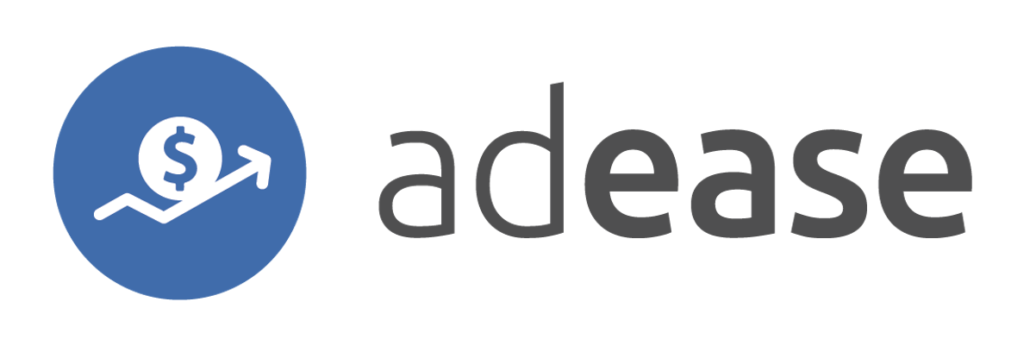

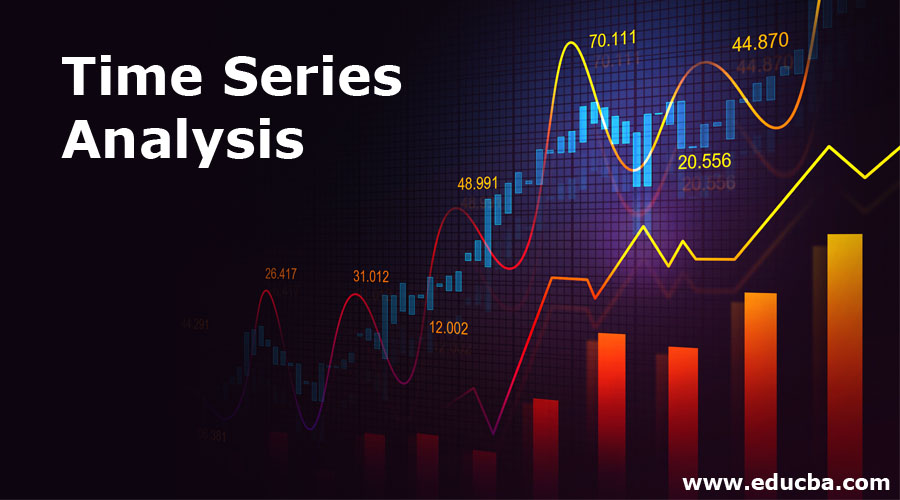

# **ABOUT Ad Ease** 💼📢✨

 - **Ad Ease** is an ads and marketing based company helping businesses elicit maximum clicks @ minimum cost. AdEase is an ad infrastructure to help businesses promote themselves easily, effectively, and economically. The interplay of 3 AI modules - Design, Dispense, and Decipher, come together to make it this an end-to-end 3 step process digital advertising solution for all.



# **What is Expected?❓👀**

- You are working in the Data Science team of Ad ease trying to understand the per page view report for different wikipedia pages for 550 days, and forecasting the number of views so that you can predict and optimize the ad placement for your clients.
- You are provided with the data of 145k wikipedia pages and daily view count for each of them. Your clients belong to different regions and need data on how their ads will perform on pages in different languages.

# **PROBLEM STATEMENT👀**

1. **To understand the per page view report for different wikipedia pages for 550 days.**

2. **Forecasting the number of views so that you can predict and optimize the ad placement for the clients.**

You are provided with the data of 145k wikipedia pages and daily view count for each of them. Your clients belong to different regions and need data on how their ads will perform on pages in different languages.

# **DATA DICTIONARY 📁**

There are two csv files given

1. **train_1.csv:** In the csv file, each row corresponds to a particular article and each column corresponds to a particular date. The values are the number of visits on that date.

The page name contains data in this format:

SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN

having information about the page name, the main domain, the device type used to access the page, and also the request origin(spider or browser agent)


2. **Exog_Campaign_eng:** This file contains data for the dates which had a campaign or significant event that could affect the views for that day. The data is just for pages in English.

There’s 1 for dates with campaigns and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in English.

# **CONCEPT USED 📑**

- Exploratory data analysis

- Time Series forecasting- ARIMA, SARIMAX, and Prophet

# **1. Define Problem Statement and perform Exploratory Data Analysis**

## **Importing Libraries 📚**

- To get insights and make better business decision, we need functions and methods, so we must import Python libraries into our work
notebook.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Loading the Dataset 🔄⏳**

In [1]:
!gdown "https://drive.google.com/uc?id=1qQkymAitU6l2pSe702rDUhQpoP8MUZXl"

Downloading...
From (original): https://drive.google.com/uc?id=1qQkymAitU6l2pSe702rDUhQpoP8MUZXl
From (redirected): https://drive.google.com/uc?id=1qQkymAitU6l2pSe702rDUhQpoP8MUZXl&confirm=t&uuid=c051d1ae-415d-4804-887a-0cbc9db7e1de
To: /content/train_1.csv
100% 278M/278M [00:02<00:00, 96.1MB/s]


In [4]:
df = pd.read_csv('train_1.csv')
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [5]:
!gdown "https://drive.google.com/uc?id=19qvuu7E8yD63o4WkOdy_lLFSrZlZPpuE"

Downloading...
From: https://drive.google.com/uc?id=19qvuu7E8yD63o4WkOdy_lLFSrZlZPpuE
To: /content/Exog_Campaign_eng
100% 1.10k/1.10k [00:00<00:00, 3.66MB/s]


In [6]:
exog_var = pd.read_csv('Exog_Campaign_eng')
exog_var.head()

,Exog
0,0
1,0
2,0
3,0
4,0


In [7]:
# Shape of the dataset

df.shape

(145063, 551)

In [8]:
exog_var.shape

(550, 1)

In [12]:
# To Get Total Elements in the Dataset (i.e., the dot product of no. of rows & columns)

df.size

79929713

In [13]:
# TO GET THE NAMES OF THE COLUMNS

df.columns

Index(['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04',
       '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08', '2015-07-09',
       ...
       '2016-12-22', '2016-12-23', '2016-12-24', '2016-12-25', '2016-12-26',
       '2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31'],
      dtype='object', length=551)

In [14]:
# To Get the name of the columns (alternate method)

df.keys()

Index(['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04',
       '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08', '2015-07-09',
       ...
       '2016-12-22', '2016-12-23', '2016-12-24', '2016-12-25', '2016-12-26',
       '2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31'],
      dtype='object', length=551)

In [11]:
# To get memory usage of each column

df.memory_usage()

,0
Index,128
Page,1160504
2015-07-01,1160504
2015-07-02,1160504
2015-07-03,1160504
...,...
2016-12-27,1160504
2016-12-28,1160504
2016-12-29,1160504
2016-12-30,1160504


In [15]:
#Dataset Info
# (i.e)info function let us know the columns with their data types and no. of non-null values & the total memory usage

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


In [16]:
df.Page.sample(20)

,Page
31177,馬雅舒_zh.wikipedia.org_all-access_all-agents
92079,Metro_es.wikipedia.org_all-access_all-agents
65755,Hawaii_Five-0_de.wikipedia.org_desktop_all-agents
80224,File:Participating_Countries_WLM_2016.svg_comm...
103858,"Ливанов,_Василий_Борисович_ru.wikipedia.org_de..."
92399,Zaha_Hadid_es.wikipedia.org_all-access_all-agents
58684,渡邉恒雄_ja.wikipedia.org_mobile-web_all-agents
18134,"Фрейзер,_Джо_ru.wikipedia.org_mobile-web_all-a..."
112080,Maurice_E._Curts_en.wikipedia.org_all-access_a...
25065,Prince_(musicien)_fr.wikipedia.org_all-access_...


In [17]:
df.Page.str.split("_").apply(lambda x:x[3]).head(20)

,Page
0,spider
1,spider
2,spider
3,spider
4,Love
5,spider
6,spider
7,spider
8,spider
9,spider


In [18]:
data = df.copy()


## **CHECK FOR DUPLICATES👬❌**

In [19]:
data.duplicated().sum()

0

**INFERENCE:**

- There are **No duplicates**.

## **MISSING VALUE DETECTION🔍**

In [20]:
df.isna().sum()

,0
Page,0
2015-07-01,20740
2015-07-02,20816
2015-07-03,20544
2015-07-04,20654
...,...
2016-12-27,3701
2016-12-28,3822
2016-12-29,3826
2016-12-30,3635


In [21]:
data.dtypes.sample(10)


,0
2016-03-11,float64
2016-06-01,float64
2016-04-30,float64
2016-11-24,float64
2015-07-08,float64
2015-07-24,float64
2016-10-17,float64
2016-06-03,float64
2015-07-23,float64
2016-07-03,float64


In [22]:
indexes = data.head(2).columns[1:][range(0,549,20)].values
indexes

array(['2015-07-01', '2015-07-21', '2015-08-10', '2015-08-30',
       '2015-09-19', '2015-10-09', '2015-10-29', '2015-11-18',
       '2015-12-08', '2015-12-28', '2016-01-17', '2016-02-06',
       '2016-02-26', '2016-03-17', '2016-04-06', '2016-04-26',
       '2016-05-16', '2016-06-05', '2016-06-25', '2016-07-15',
       '2016-08-04', '2016-08-24', '2016-09-13', '2016-10-03',
       '2016-10-23', '2016-11-12', '2016-12-02', '2016-12-22'],
      dtype=object)

<Axes: >

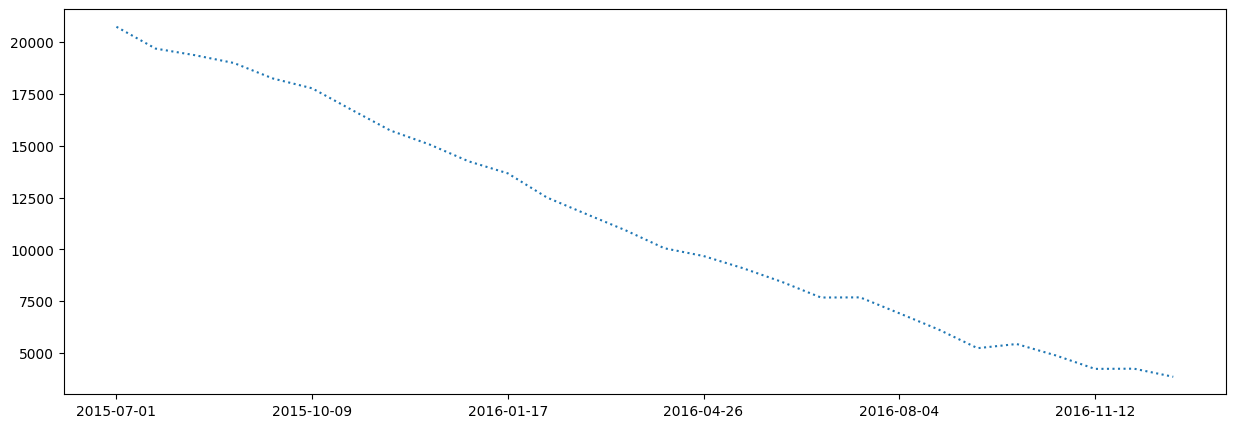

In [23]:
plt.figure(figsize=(15, 5))

data.isna().sum()[indexes].plot(linestyle='dotted')

**INFERENCE:**

- From above plot , we can observe that with time , **null values are decreasing**.

- **Recent dates have lesser null values**, that means newer pages will have no data of prior to that page hosting date.

## **TREATING MISSING VALUES 🧹**

In [24]:
# replacing all the null values with 0.

data.fillna(0,inplace =True)


In [25]:
data.isnull().sum()[indexes]

,0
2015-07-01,0
2015-07-21,0
2015-08-10,0
2015-08-30,0
2015-09-19,0
2015-10-09,0
2015-10-29,0
2015-11-18,0
2015-12-08,0
2015-12-28,0


## **EXPLORATORY DATA ANALYSIS 📊📈**

Extracting Language , access type and access origin
The page name contains data in this format:

SPECIFICNAME_LANGUAGE.wikipedia.org_ACCESS TYPE_ ACCESS ORIGIN

### **Extracting Language**

In [26]:
data.Page[0]


'2NE1_zh.wikipedia.org_all-access_spider'

In [27]:
import re
re.findall(r'_(.{2}).wikipedia.org_', "2NE1_zh.wikipedia.org_all-access_spider")

['zh']

In [28]:
data.Page.str.findall(pat="_(.{2}).wikipedia.org_").sample(10)

,Page
134467,[ja]
27963,[fr]
26911,[fr]
96550,[es]
31284,[zh]
1606,[zh]
91597,[es]
124076,[ru]
57533,[ja]
44138,[]


In [45]:
# extracting language
def Extract_Language(name):
  if len(re.findall(r'_(.{2}).wikipedia.org_', name)) == 1 :
    return re.findall(r'_(.{2}).wikipedia.org_', name)[0]
  else:
    return 'Unknown'


In [46]:
data["Language"] = data["Page"].map(Extract_Language)


In [47]:
data["Language"].unique()


array(['zh', 'fr', 'en', 'Unknown', 'ru', 'de', 'ja', 'es'], dtype=object)

In [48]:
dict_ = {'de':'German',
        'en':'English',
        'es': 'Spanish',
        'fr': 'French',
        'ja': 'Japenese' ,
        'ru': 'Russian',
        'zh': 'Chinese',
        'Unknown': 'Unknown_Language'}



In [49]:
data["Language"] = data["Language"].map(dict_).fillna(data["Language"])

In [50]:
data.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Language
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0,Chinese
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0,Chinese
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0,Chinese
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0,Chinese
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0,Chinese


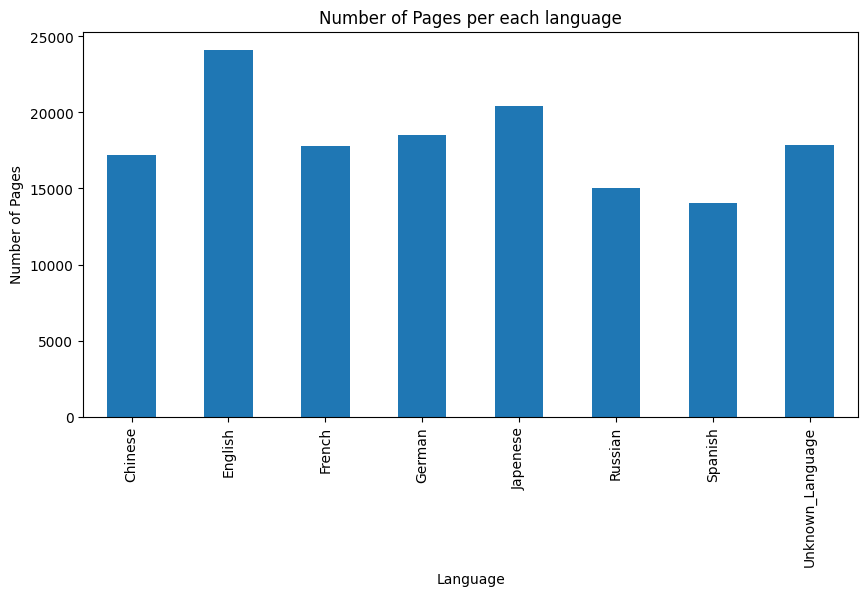

In [51]:
plt.figure(figsize=(10, 5))

data.groupby("Language")["Page"].count().plot(kind="bar")
plt.xlabel("Language")
plt.ylabel("Number of Pages")
plt.title("Number of Pages per each language")
plt.show()

In [52]:
from locale import normalize
data["Language"].value_counts(normalize=True) * 100

,proportion
Language,
English,16.618986
Japenese,14.084225
German,12.785479
Unknown_Language,12.308445
French,12.271909
Chinese,11.876909
Russian,10.355501
Spanish,9.698545


**INFERENCE:**

- **English** is the **most used language** (**16.6%**), followed closely by **Japanese** (**14.1%**) and **German** (**12.8%**).

- **French, Chinese, Russian**, and **Spanish** have lower usage, with Spanish being the least common (**9.7%**).

- **Unknown Language** makes up **12.3%**, which could mean some entries don’t have a recognized language.

Overall, there's a diverse range of languages, with English and Japanese being the most common.

### **Exrtacting ACCESS TYPE:**

SPECIFICNAME_LANGUAGE.wikipedia.org_ACCESS TYPE_ ACCESS ORIGIN

In [53]:
data.Page[0]

'2NE1_zh.wikipedia.org_all-access_spider'

In [54]:
data["Access_Type"] = data.Page.str.findall(r'all-access|mobile-web|desktop').apply(lambda x:x[0])


In [55]:
data["Access_Type"].value_counts(dropna=False, normalize=True)


,proportion
Access_Type,
all-access,0.512295
mobile-web,0.247748
desktop,0.239958


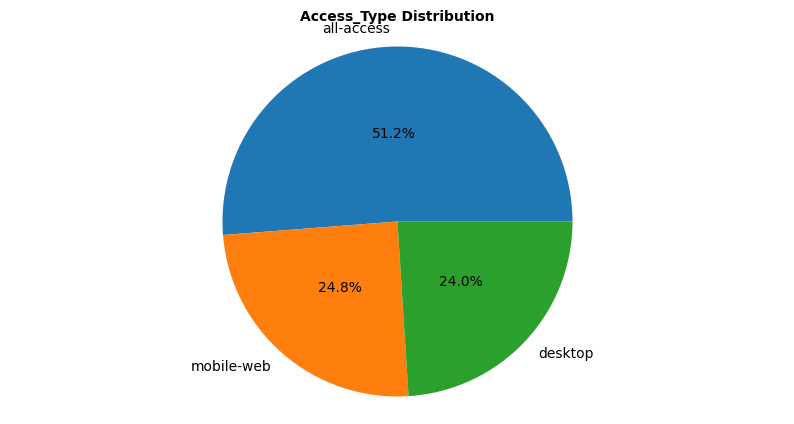

In [56]:
x = (data["Access_Type"].value_counts(dropna= False, normalize=True) * 100).values
y = (data["Access_Type"].value_counts(dropna= False, normalize=True) * 100).index

plt.figure(figsize=(10, 5))

plt.pie(x,labels= y,radius=1.5,  autopct='%1.1f%%', pctdistance=0.5 )
plt.title(f'Access_Type Distribution', fontsize = 10, fontweight = 'bold')
plt.axis('equal')
plt.show()


### **Exrtacting ACCESS ORIGIN :**

SPECIFICNAME_LANGUAGE.wikipedia.org_ACCESS TYPE_ ACCESS ORIGIN

In [57]:
data.Page.sample(20)

,Page
9185,Gerald_Ford_en.wikipedia.org_desktop_all-agents
98690,"Лебедев,_Денис_Александрович_ru.wikipedia.org_..."
64071,燦爛時光_(電視劇)_zh.wikipedia.org_desktop_all-agents
48978,Flagge_der_Vereinigten_Staaten_de.wikipedia.or...
1231,陳柏霖_zh.wikipedia.org_all-access_spider
44210,Category:Sexual_arousal_commons.wikimedia.org_...
123485,ツキウタ。_ja.wikipedia.org_all-access_all-agents
61357,卡羅琳·赫歇爾_zh.wikipedia.org_desktop_all-agents
111339,International_Children's_Peace_Prize_en.wikipe...
26189,Loana_Petrucciani_fr.wikipedia.org_all-access_...


In [58]:
data.Page.str.findall(r'spider|agents').apply(lambda x:x[0]).isna().sum()


0

In [59]:
data["Access_Origin"] =  data.Page.str.findall(r'spider|agents').apply(lambda x:x[0])


In [60]:
data["Access_Origin"].value_counts(dropna= False, normalize=True) * 100


,proportion
Access_Origin,
agents,75.932526
spider,24.067474


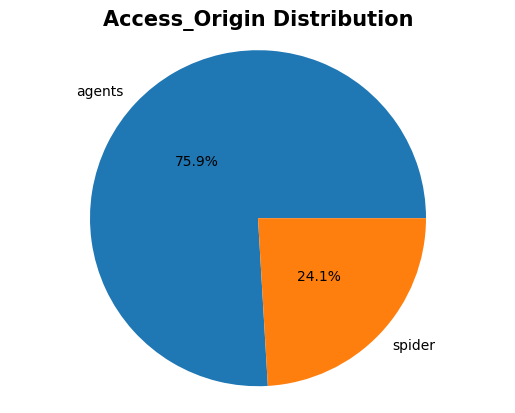

In [61]:
x = (data["Access_Origin"].value_counts(dropna= False, normalize=True) * 100).values
y = (data["Access_Origin"].value_counts(dropna= False, normalize=True) * 100).index

plt.pie(x,labels= y,radius=1.5,  autopct='%1.1f%%', pctdistance=0.5 )
plt.title(f'Access_Origin Distribution', fontsize = 15, fontweight = 'bold')
plt.axis('equal')
plt.show()


### **Grouping By Language**

In [62]:
data

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Language,Access_Type,Access_Origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,26.0,14.0,20.0,22.0,19.0,18.0,20.0,Chinese,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,15.0,9.0,30.0,52.0,45.0,26.0,20.0,Chinese,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,7.0,4.0,4.0,6.0,3.0,4.0,17.0,Chinese,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,27.0,16.0,11.0,17.0,19.0,10.0,11.0,Chinese,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,13.0,3.0,11.0,27.0,13.0,36.0,10.0,Chinese,all-access,spider
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,13.0,12.0,13.0,3.0,5.0,10.0,Spanish,all-access,spider
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spanish,all-access,spider
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spanish,all-access,spider
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spanish,all-access,spider


In [63]:
agg_data = data.drop(['Page','Access_Type','Access_Origin'],axis=1)

In [64]:
agg_data.groupby("Language").mean()


,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
Language,,,,,,,,,,,,,,,,,,,,,
Chinese,240.582042,240.941958,239.344071,241.653491,257.779674,259.114864,258.832260,265.589529,263.964420,274.414592,...,345.165129,340.420338,360.738580,381.322886,376.447443,376.019618,378.048639,350.719427,354.704452,365.579256
English,3513.862203,3502.511407,3325.357889,3462.054256,3575.520035,3849.736021,3643.523063,3437.871080,3517.459391,3497.571594,...,4997.991248,4683.314294,4971.831757,5140.463373,5770.371661,6040.680728,5860.227559,6245.127510,5201.783018,5127.916418
French,475.150994,478.202000,459.837659,491.508932,482.557746,502.741209,485.945399,476.998820,472.061903,445.495057,...,652.004719,639.459443,618.215931,666.639085,936.884788,858.413100,774.155769,752.712954,700.543422,646.258342
German,714.968405,705.229741,676.877231,621.145145,722.076185,794.832480,770.814256,782.077641,752.939990,701.702593,...,828.738017,839.025934,810.756187,1281.088532,1206.478029,1085.095379,1032.640804,994.657141,949.265649,893.013425
Japenese,580.647056,666.672801,602.289805,756.509177,725.720914,632.399148,615.184181,611.462337,596.067642,619.299300,...,675.104792,968.007733,856.605012,818.374725,779.114728,789.158680,790.500465,865.483236,952.018354,1197.239440
Russian,629.999601,640.902876,594.026295,558.728132,595.029157,640.986287,626.293436,623.360205,638.550726,731.252297,...,896.352017,884.841299,874.274597,1120.990347,1112.840833,1001.209426,931.987685,897.282452,803.271868,880.244508
Spanish,1085.972919,1037.814557,954.412680,896.050750,974.508210,1110.637145,1082.568342,1050.669557,1030.841282,937.129931,...,983.568129,935.082522,880.307911,903.643685,1195.481626,1133.367901,1178.290923,1112.171085,821.671405,787.399531
Unknown_Language,83.479922,87.471857,82.680538,70.572557,78.214562,89.720190,94.939457,99.096724,86.445477,87.353906,...,131.521983,164.889051,140.363764,164.455167,165.821563,147.038925,186.438029,147.297004,164.540577,143.951442


In [65]:
pd.set_option('display.max_rows', 500)


In [66]:
aggregated_data = agg_data.groupby("Language").mean().T.drop("Unknown_Language",axis = 1).reset_index()


In [67]:
aggregated_data["index"] = pd.to_datetime(aggregated_data["index"])
aggregated_data = aggregated_data.set_index("index")


In [68]:
aggregated_data

Language,Chinese,English,French,German,Japenese,Russian,Spanish
index,,,,,,,
2015-07-01,240.582042,3513.862203,475.150994,714.968405,580.647056,629.999601,1085.972919
2015-07-02,240.941958,3502.511407,478.202000,705.229741,666.672801,640.902876,1037.814557
2015-07-03,239.344071,3325.357889,459.837659,676.877231,602.289805,594.026295,954.412680
2015-07-04,241.653491,3462.054256,491.508932,621.145145,756.509177,558.728132,896.050750
2015-07-05,257.779674,3575.520035,482.557746,722.076185,725.720914,595.029157,974.508210
...,...,...,...,...,...,...,...
2016-12-27,376.019618,6040.680728,858.413100,1085.095379,789.158680,1001.209426,1133.367901
2016-12-28,378.048639,5860.227559,774.155769,1032.640804,790.500465,931.987685,1178.290923
2016-12-29,350.719427,6245.127510,752.712954,994.657141,865.483236,897.282452,1112.171085


In [69]:
aggregated_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 550 entries, 2015-07-01 to 2016-12-31
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Chinese   550 non-null    float64
 1   English   550 non-null    float64
 2   French    550 non-null    float64
 3   German    550 non-null    float64
 4   Japenese  550 non-null    float64
 5   Russian   550 non-null    float64
 6   Spanish   550 non-null    float64
dtypes: float64(7)
memory usage: 34.4 KB


In [70]:
aggregated_data.index

DatetimeIndex(['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04',
               '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08',
               '2015-07-09', '2015-07-10',
               ...
               '2016-12-22', '2016-12-23', '2016-12-24', '2016-12-25',
               '2016-12-26', '2016-12-27', '2016-12-28', '2016-12-29',
               '2016-12-30', '2016-12-31'],
              dtype='datetime64[ns]', name='index', length=550, freq=None)

## **Visualising Time Series for Each Languages 📊📈📉**

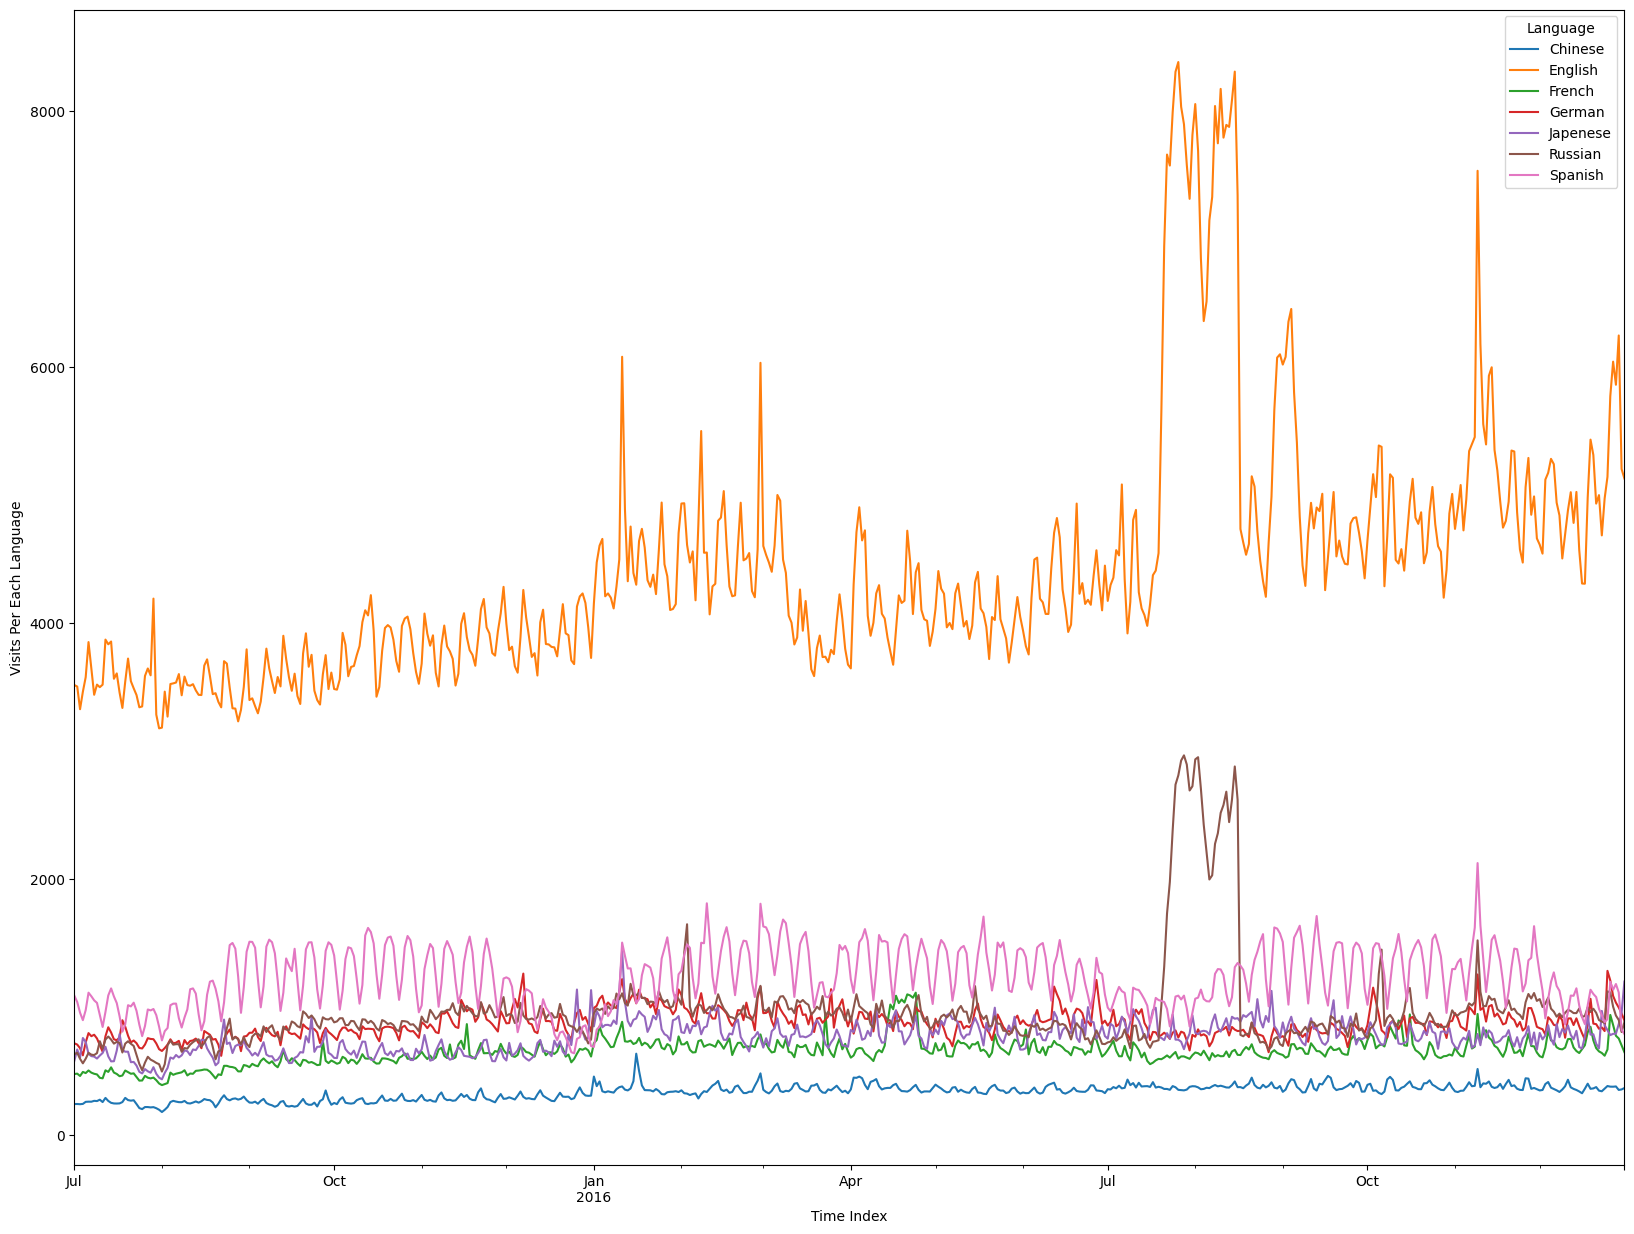

In [71]:
plt.rcParams['figure.figsize'] = (20, 15)

aggregated_data.plot()

plt.xlabel("Time Index")
plt.ylabel("Visits Per Each Language")
plt.show()

### **Hypothesis Testing : if Time Series is Stationary or Trending :**

**Null Hypothesis:** The Time Series is Non-Stationary

**Alternative Hypothesis:** The Time Series is Stationary

significant value : 0.05 (alpha)

if **p-value > 0.05** : we **failed to reject Null hypothesis** (the Time Series is Non-Stationary)

if p-value <= 0.05: we reject Null Hypothesis (the Time Series in Stationary)



In [72]:
import statsmodels.api as sm

In [73]:
def Dickey_Fuller_test(ts,significances_level = 0.05):
    p_value = sm.tsa.stattools.adfuller(ts)[1]
    if p_value <= significances_level:
        print("Time Series is Stationary")
    else:
        print("Time Series is NOT Stationary")
    print("P_value is: ", p_value)


In [77]:
for Language in aggregated_data.columns:
  print(Language)
  print(Dickey_Fuller_test(aggregated_data[Language],significances_level = 0.05))
  print()


Chinese
Time Series is NOT Stationary
P_value is:  0.4474457922931142
None

English
Time Series is NOT Stationary
P_value is:  0.18953359279992404
None

French
Time Series is NOT Stationary
P_value is:  0.05149502195245795
None

German
Time Series is NOT Stationary
P_value is:  0.14097382319729534
None

Japenese
Time Series is NOT Stationary
P_value is:  0.10257133898557641
None

Russian
Time Series is Stationary
P_value is:  0.0018649376536617886
None

Spanish
Time Series is Stationary
P_value is:  0.033588590844791
None



INFERENCE:

Based on the **Dickey-Fuller Test for Stationarity**,

- The **Time Series** for page visits in **Spanish and Russian are Stationary**.

- In contrast, the **Time Series** for **Chinese, English, German, Japanese, and French are Non-Stationary**.

### **Further analysing Time Series for English Language Pages Visits**

In [78]:
TS_English = aggregated_data.English

In [79]:

def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')

    dftest = sm.tsa.stattools.adfuller(timeseries, autolag='AIC')
    df_output = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in dftest[4].items():
       df_output['Critical Value (%s)' %key] = value
    print (df_output)


In [80]:
adf_test(TS_English)

Results of Dickey-Fuller Test:
Test Statistic                  -2.247284
p-value                          0.189534
#Lags Used                      14.000000
Number of Observations Used    535.000000
Critical Value (1%)             -3.442632
Critical Value (5%)             -2.866957
Critical Value (10%)            -2.569655
dtype: float64


In [81]:
Dickey_Fuller_test(TS_English)


Time Series is NOT Stationary
P_value is:  0.18953359279992404


### **Visualising English-Language Page Visits Time Series manually to identify seasonality and period :**

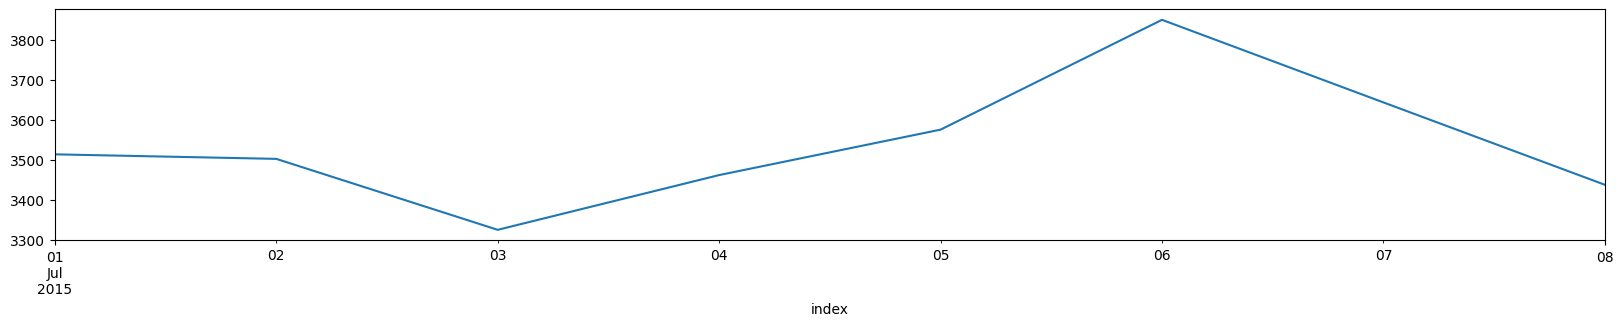

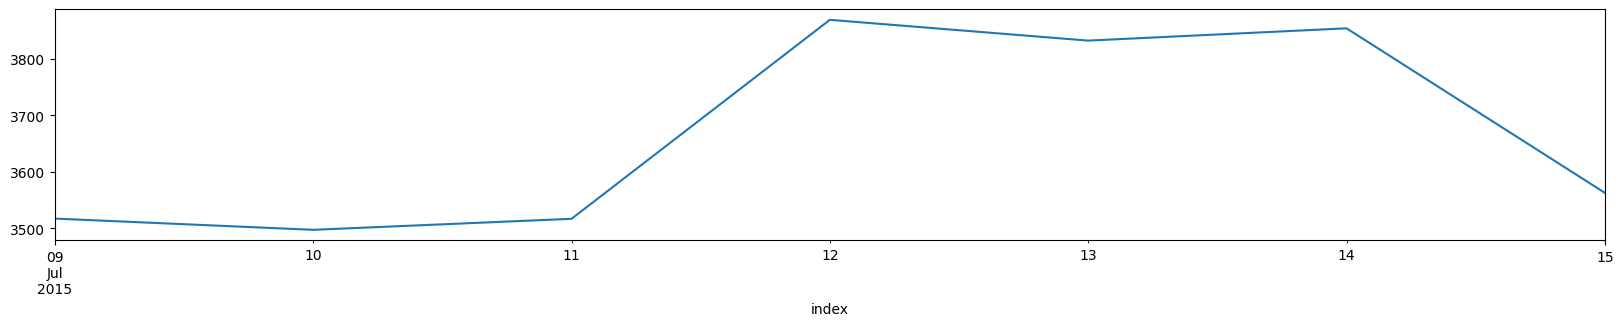

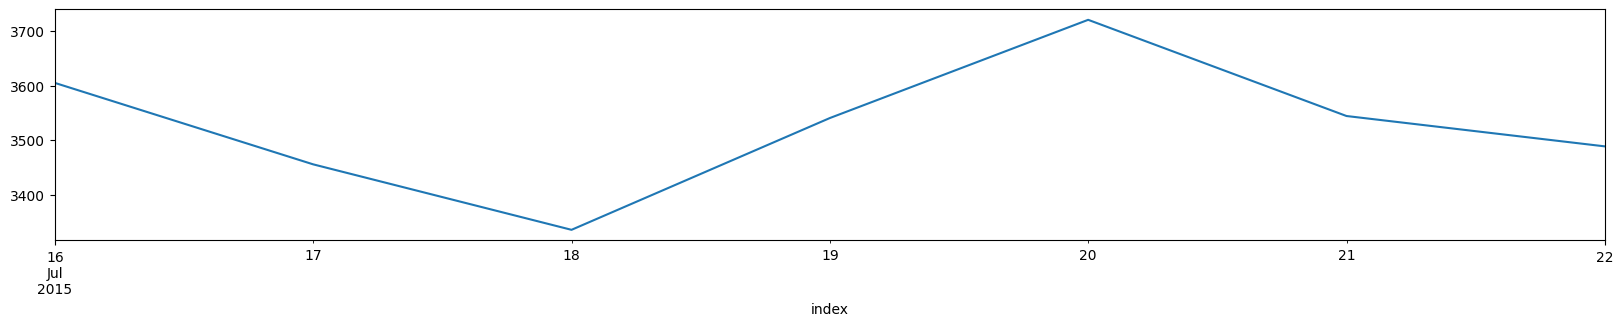

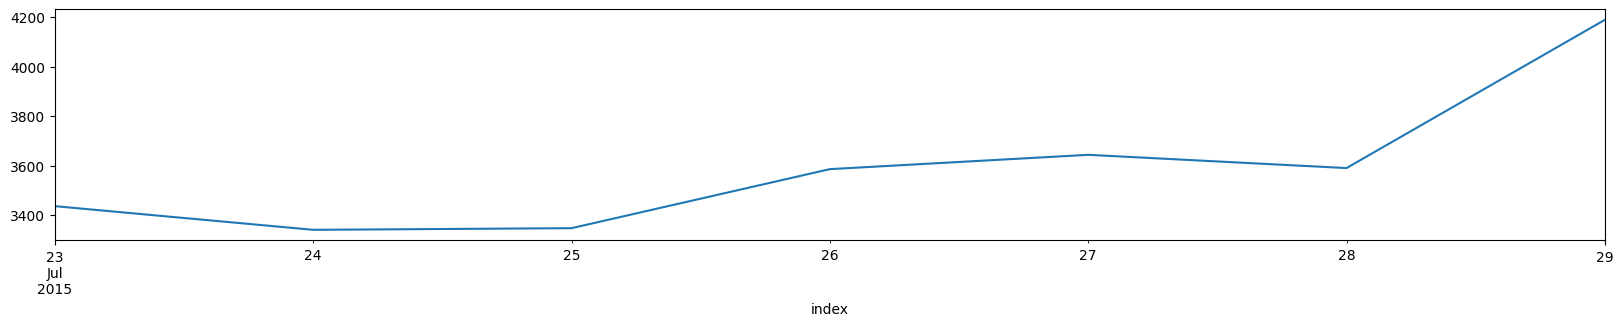

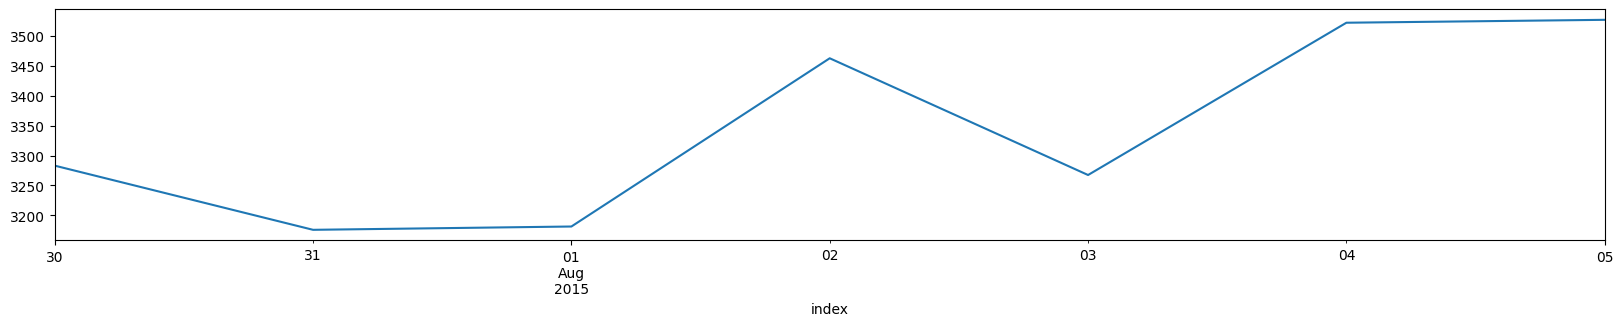

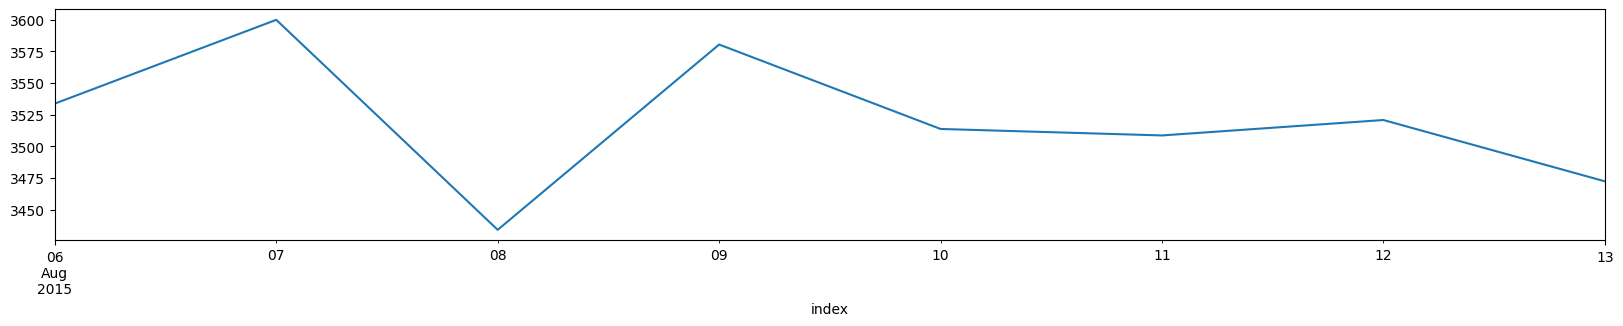

In [82]:
plt.rcParams['figure.figsize'] = (20, 3)

TS_English[:8].plot()
plt.show()
TS_English[8:15].plot()
plt.show()
TS_English[15:22].plot()
plt.show()
TS_English[22:29].plot()
plt.show()
TS_English[29:36].plot()
plt.show()

TS_English[36:44].plot()
plt.show()


In [83]:
correlations = []
for lag in range(1,30):
    present = TS_English[:-lag]
    past = TS_English.shift(-lag)[:-lag]
    corrs = np.corrcoef(present,past)[0][-1]
    print(lag,corrs)
    correlations.append(corrs)

1 0.9363434527458435
2 0.8682966716039896
3 0.8185418037184544
4 0.7846718829500342
5 0.7612561076942573
6 0.7542260641783559
7 0.7386829287516693
8 0.6912638018189877
9 0.6370978014300401
10 0.6015277501876303
11 0.5825450402423571
12 0.5812931934793534
13 0.6007266462817789
14 0.6142525351445116
15 0.5971084554755528
16 0.5693834937428246
17 0.5488401467532626
18 0.5377431132136109
19 0.5430816743411203
20 0.5552694244923043
21 0.5540623423718063
22 0.5092655604869363
23 0.45373695576813583
24 0.4112336297620323
25 0.38162860616251737
26 0.3651996316699481
27 0.3723603627302601
28 0.37818226683160033
29 0.35939242667328175


# **ACF and PACF Plots**

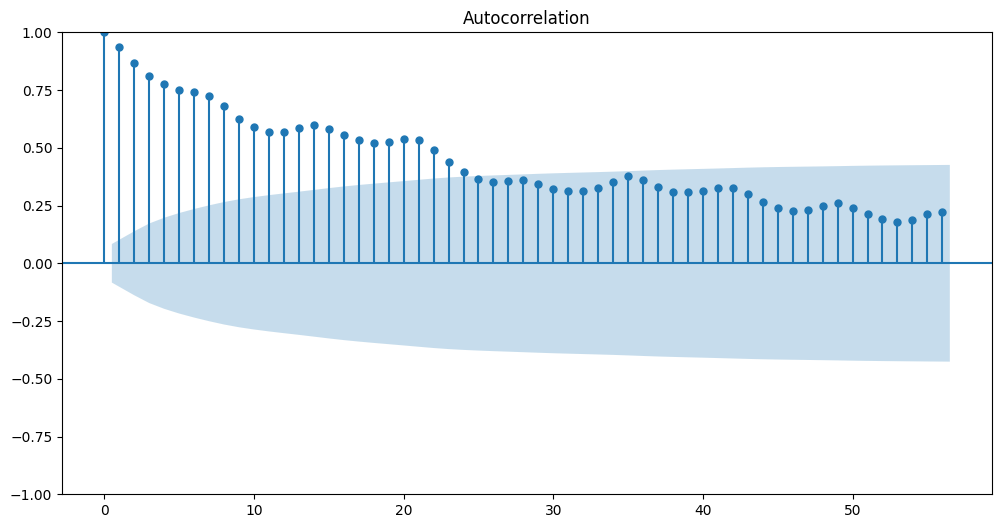

In [84]:
# using auto correlation function plot , to varify the period

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plt.rcParams['figure.figsize'] = (12, 6)
plot_acf(TS_English,lags=56);

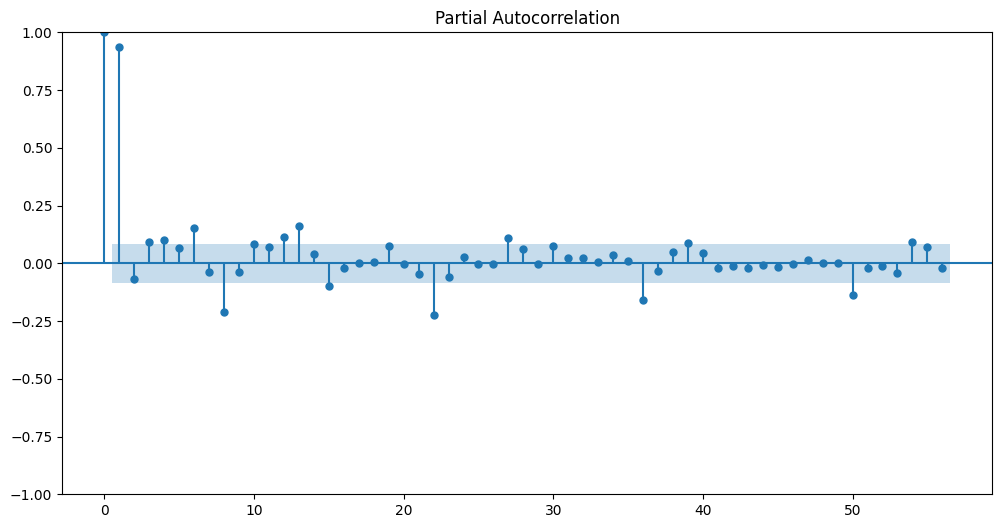

In [85]:
plot_pacf(TS_English,lags=56);

**INFERENCE:**

- The **ACF and PACF plots** indicate a **7-period cycle** in the data, suggesting a **weekly pattern** in the time series.

# **Time Series Decomposition**

 Y(t) = seasonality + trend + residuals

           $$Y(t) = S(t) + T(t) + R(t)$$

    where:

    - \( S(t) \) is the seasonality component,
    - \( T(t) \) is the trend component,
    - \( R(t) \) is the residual (or noise) component.


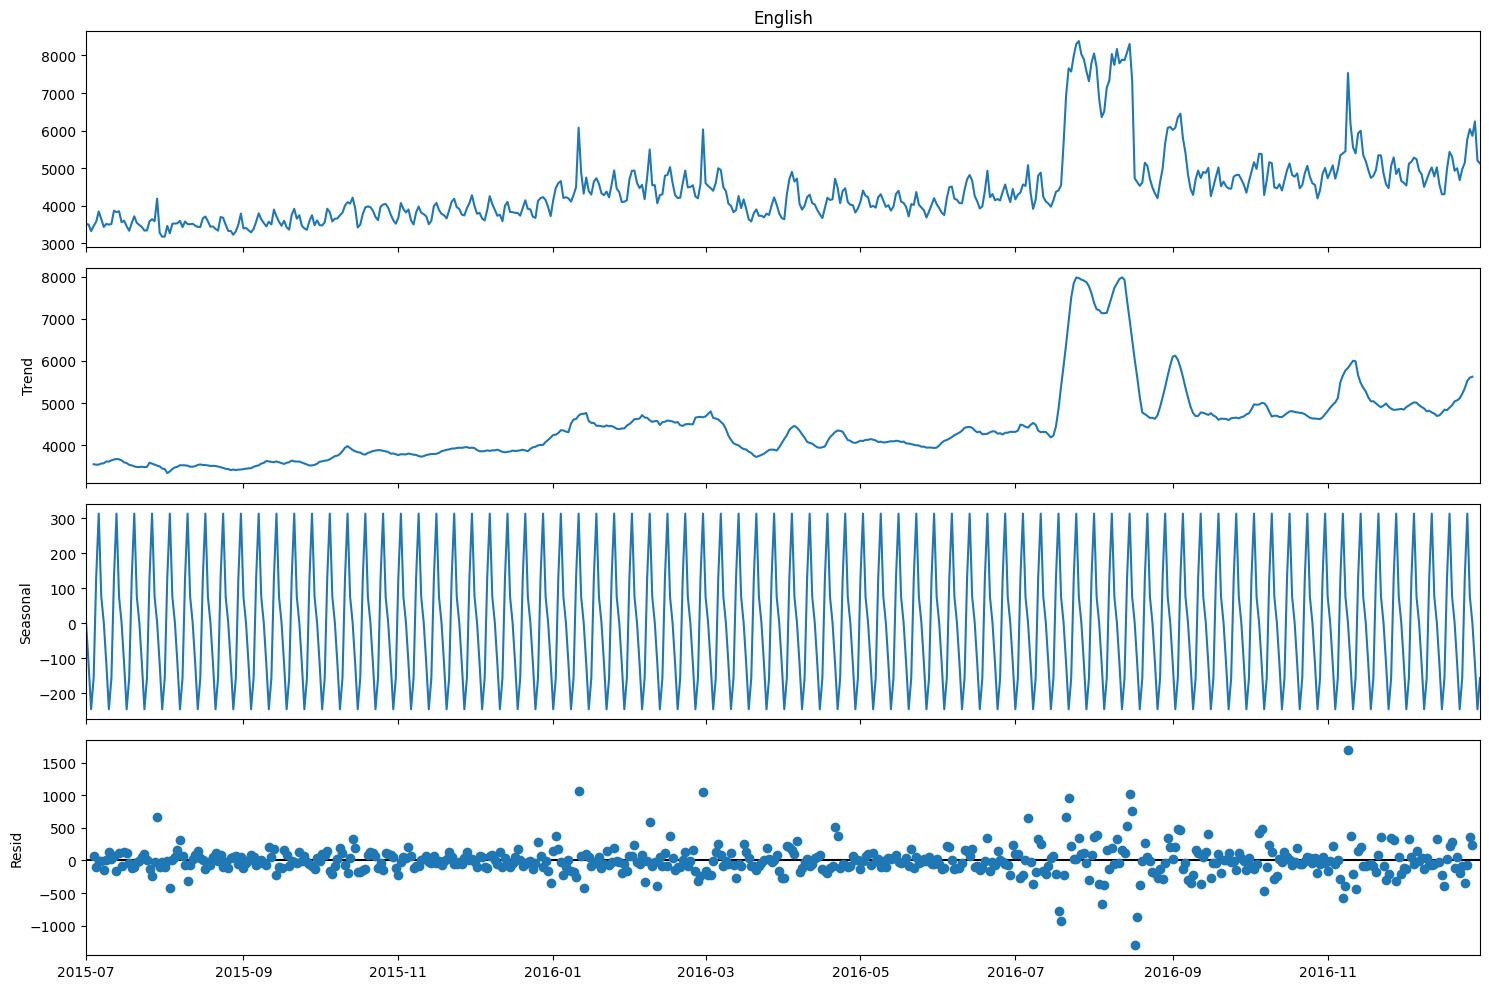

In [87]:
plt.rcParams['figure.figsize'] = (15, 10)

Decomposition_model = sm.tsa.seasonal_decompose(TS_English, model='additive',period=7)
Decomposition_model.plot();

In [88]:
Dickey_Fuller_test(pd.Series(Decomposition_model.resid).fillna(0))

Time Series is Stationary
P_value is:  3.727526947813056e-21


**INFERENCE:**

- **Residuals from Time Series Decomposition are Stationary**.

<Axes: xlabel='index'>

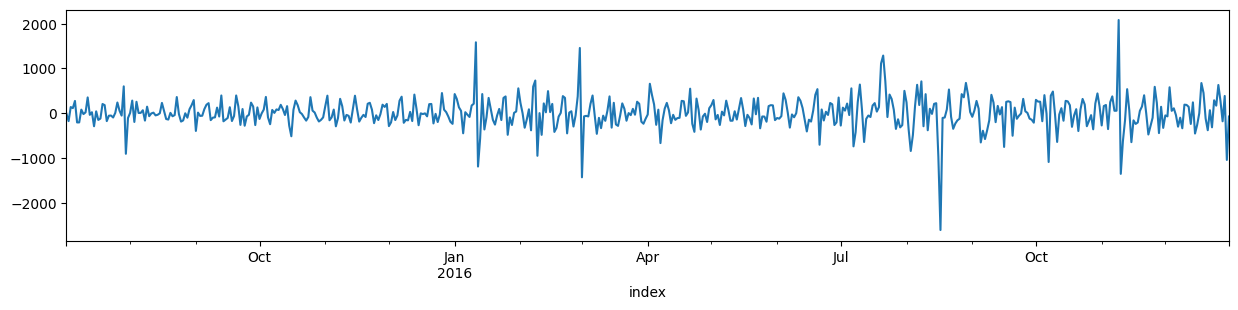

In [89]:
# Taking the first differentiation of the time series and plotting

plt.rcParams['figure.figsize'] = (15, 3)

TS_English.diff(1).dropna().plot()

In [90]:
Dickey_Fuller_test(TS_English.diff(1).dropna())

Time Series is Stationary
P_value is:  5.292474635436075e-13


**INFERENCE:**

- After 1 differentiation , Time series becomes Stationary.

- Thus for **ARIMA** models , we can set **d=1**

## **PERFORMANCE METRICS**

In [91]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

# **FORECASTING**

## **Trying out ExponentialSmoothing Method**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='index'>

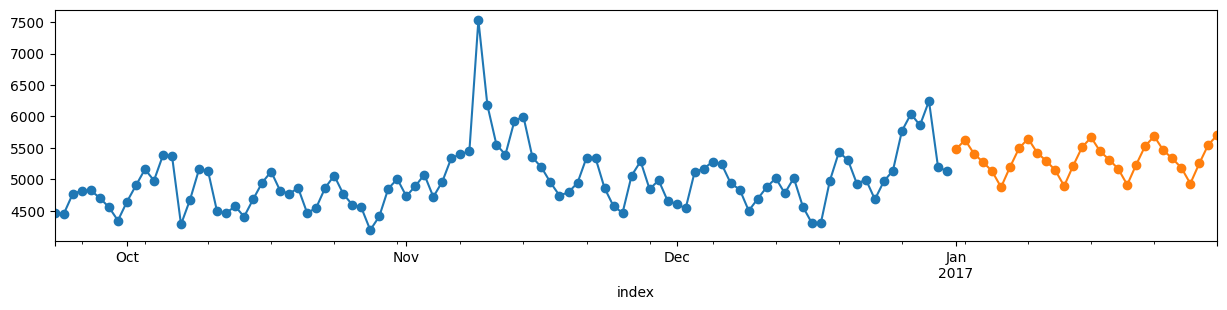

In [92]:
model = sm.tsa.ExponentialSmoothing(TS_English, seasonal='add',trend="add")
model = model.fit()
                                                     # default values
                                                     # of smoothing_level, seasonal_smoothing and
                                                     # and trend smoothing

TS_English.tail(100).plot(style='-o', label='actual')
model.forecast(30).plot(style='-o', label='predicted')


MAE : 394.976
RMSE : 563.349
MAPE: 0.073


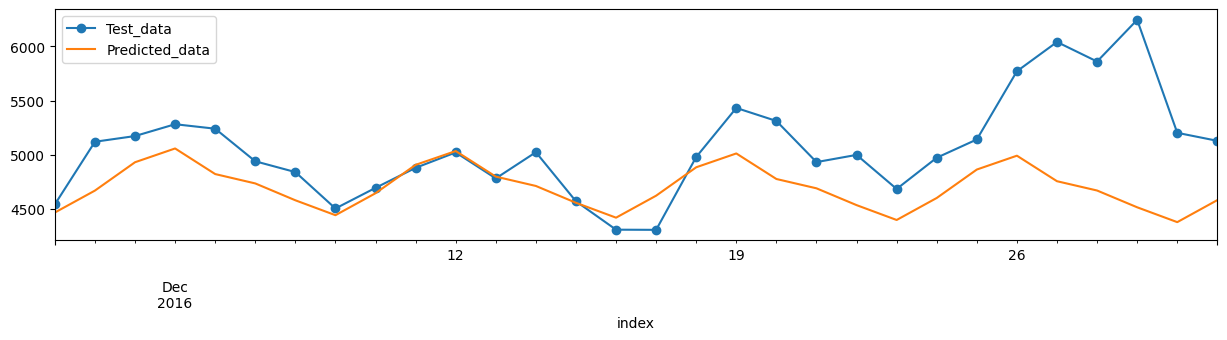

In [93]:
X_train = TS_English.loc[TS_English.index < TS_English.index[-30] ].copy()
X_test = TS_English.loc[TS_English.index >= TS_English.index[-30] ].copy()

import warnings # supress warnings
warnings.filterwarnings('ignore')


model = sm.tsa.ExponentialSmoothing(X_train,
                                    trend="add",
                                    damped_trend="add",
                                    seasonal="add")
model = model.fit(smoothing_level=None,    # alpha
            smoothing_trend=None,          # beta
            smoothing_seasonal=None)       # gama)

# X_test.plot()
Pred = model.forecast(steps=30)
performance(X_test,Pred)

X_test.plot(style="-o",label ="Test_data")
Pred.plot(label="Predicted_data")
plt.legend()
plt.show()

# **ARIMA MODEL**

**Autoregressive Integrated Moving Average (ARIMA) model**, and extensions This model is the basic interface for ARIMA-type models, including those with exogenous regressors and those with seasonal components. The most general form of the model is SARIMAX(p, d, q)x(P, D, Q, s). It also allows all specialized cases, including

1. Autoregressive Models: **AR(p)**

2. Moving Average Models: **MA(q)**

3. Mixed Autoregressive Moving Average Models: **ARMA(p, q)**

4. Integration Models: **ARIMA(p, d, q)**

5. Seasonal Models: **SARIMA(P, D, Q, s)**

Regression with errors that follow one of the above ARIMA-type models

In [94]:
from statsmodels.tsa.arima.model import ARIMA

In [95]:
TS = TS_English.copy(deep=True)

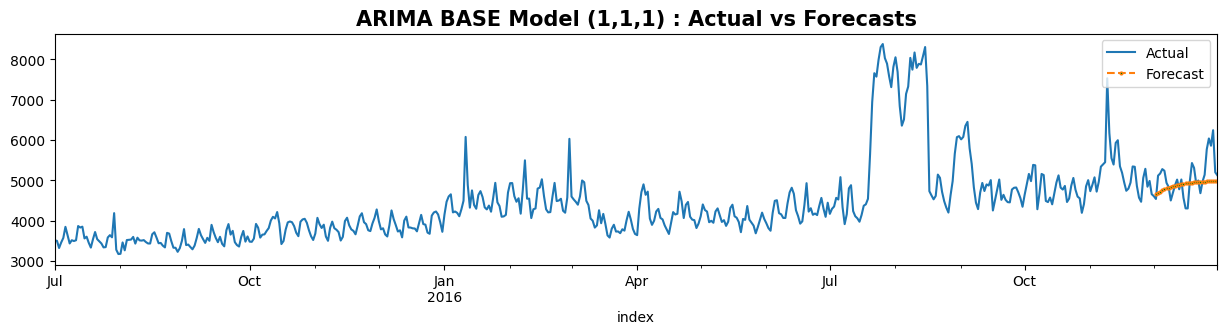


RMSE of Model : 472.186
MAPE of Model : 0.06585


In [96]:
n_forecast = 30

model = ARIMA(TS[:-n_forecast],
              order = (1,1,1))

model = model.fit()

predicted = model.forecast(steps= n_forecast, alpha = 0.05)


TS.plot(label = 'Actual')
predicted.plot(label = 'Forecast', linestyle='dashed', marker='o',markerfacecolor='green', markersize=2)
plt.legend(loc="upper right")
plt.title('ARIMA BASE Model (1,1,1) : Actual vs Forecasts', fontsize = 15, fontweight = 'bold')
plt.show()

#Calculating MAPE & RMSE
actuals = TS.values[-n_forecast:]
errors = TS.values[-n_forecast:] - predicted.values

mape = np.mean(np.abs(errors)/ np.abs(actuals))
rmse = np.sqrt(np.mean(errors**2))

print()
print(f'RMSE of Model : {np.round(rmse,3)}')
print(f'MAPE of Model : {np.round(mape,5)}')


# **SARIMAX MODEL**

In [97]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [99]:
def sarimax_model(time_series, n, p=0, d=0, q=0, P=0, D=0, Q=0, s=0, exog = []):

    #Creating SARIMAX Model with order(p,d,q) & seasonal_order=(P, D, Q, s)
    model = SARIMAX(time_series[:-n], \
                    order =(p,d,q),
                    seasonal_order=(P, D, Q, s),
                    exog = exog[:-n],
                    initialization='approximate_diffuse')
    model_fit = model.fit()

    #Creating forecast for last n-values
    model_forecast = model_fit.forecast(n, dynamic = True, exog = pd.DataFrame(exog[-n:]))

    #plotting Actual & Forecasted values

    plt.figure(figsize = (20,8))
    time_series[-60:].plot(label = 'Actual')
    model_forecast[-60:].plot(label = 'Forecast', color = 'red',
                              linestyle='dashed', marker='o',markerfacecolor='green', markersize=5)
    plt.legend(loc="upper right")
    plt.title(f'SARIMAX Model ({p},{d},{q}) ({P},{D},{Q},{s}) : Actual vs Forecasts', fontsize = 15, fontweight = 'bold')
    plt.show()

    #Calculating MAPE & RMSE
    actuals = time_series.values[-n:]
    errors = time_series.values[-n:] - model_forecast.values

    mape = np.mean(np.abs(errors)/ np.abs(actuals))
    rmse = np.sqrt(np.mean(errors**2))

    print()
    print(f'RMSE of Model : {np.round(rmse,3)}')
    print(f'MAPE of Model : {np.round(mape,5)}')



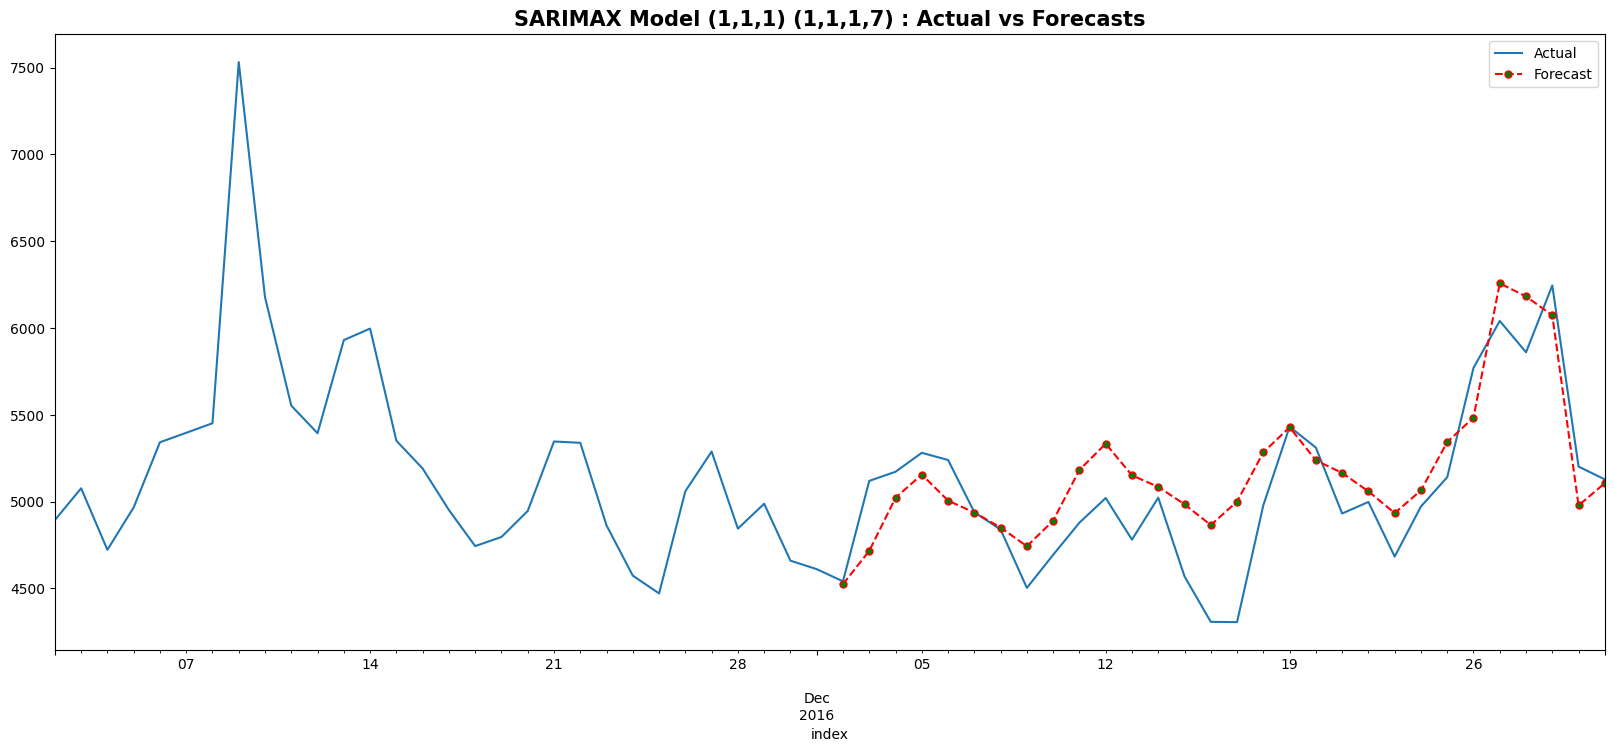


RMSE of Model : 272.731
MAPE of Model : 0.04453


In [100]:
exog = exog_var['Exog'].to_numpy()
time_series = aggregated_data.English
test_size= 0.1
p,d,q, P,D,Q,s = 1,1,1,1,1,1,7
n = 30
sarimax_model(time_series, n, p=p, d=d, q=q, P=P, D=D, Q=Q, s=s, exog = exog)


### **HYPERPARAMETER TUNING FOR SARIMAX MODEL**

In [101]:
def SARIMAX_grid_search(time_series, n, param, d_param, s_param, exog = []):
    counter = 0
    #creating df for storing results summary
    param_df = pd.DataFrame(columns = ['serial','pdq', 'PDQs', 'mape', 'rmse'])

    #Creating loop for every paramater to fit SARIMAX model
    for p in param:
        for d in d_param:
            for q in param:
                for P in param:
                    for D in d_param:
                        for Q in param:
                            for s in s_param:
                                #Creating Model
                                model = SARIMAX(time_series[:-n],
                                                order=(p,d,q),
                                                seasonal_order=(P, D, Q, s),
                                                exog = exog[:-n],
                                                initialization='approximate_diffuse')
                                model_fit = model.fit()

                                #Creating forecast from Model
                                model_forecast = model_fit.forecast(n, dynamic = True, exog = pd.DataFrame(exog[-n:]))

                                #Calculating errors for results
                                actuals = time_series.values[-n:]
                                errors = time_series.values[-n:] - model_forecast.values

                                #Calculating MAPE & RMSE
                                mape = np.mean(np.abs(errors)/ np.abs(actuals))
                                rmse = np.sqrt(np.mean(errors**2))
                                mape = np.round(mape,5)
                                rmse = np.round(rmse,3)

                                #Storing the results in param_df
                                counter += 1
                                list_row = [counter, (p,d,q), (P,D,Q,s), mape, rmse]
                                param_df.loc[len(param_df)] = list_row

                #print statement to check progress of Loop
                print(f'Possible Combination: {counter} out of { (len(param)**4)*len(s_param)*(len(d_param)**2)} calculated')

    return param_df


In [102]:
#Finding best parameters for English time series

exog = exog_var['Exog'].to_numpy()
time_series = aggregated_data.English
n = 30
param = [0,1,2]
d_param = [0,1]
s_param = [7]

english_params  = SARIMAX_grid_search(time_series, n, param, d_param,s_param, exog)


Possible Combination: 18 out of 324 calculated
Possible Combination: 36 out of 324 calculated
Possible Combination: 54 out of 324 calculated
Possible Combination: 72 out of 324 calculated
Possible Combination: 90 out of 324 calculated
Possible Combination: 108 out of 324 calculated
Possible Combination: 126 out of 324 calculated
Possible Combination: 144 out of 324 calculated
Possible Combination: 162 out of 324 calculated
Possible Combination: 180 out of 324 calculated
Possible Combination: 198 out of 324 calculated
Possible Combination: 216 out of 324 calculated
Possible Combination: 234 out of 324 calculated
Possible Combination: 252 out of 324 calculated
Possible Combination: 270 out of 324 calculated
Possible Combination: 288 out of 324 calculated
Possible Combination: 306 out of 324 calculated
Possible Combination: 324 out of 324 calculated


In [103]:
english_params.sort_values(['mape', 'rmse']).head()

,serial,pdq,PDQs,mape,rmse
317,318,"(2, 1, 2)","(1, 1, 2, 7)",0.04054,246.918
209,210,"(1, 1, 2)","(1, 1, 2, 7)",0.04163,252.820
323,324,"(2, 1, 2)","(2, 1, 2, 7)",0.04197,258.336
40,41,"(0, 0, 2)","(0, 1, 1, 7)",0.04199,276.311
41,42,"(0, 0, 2)","(0, 1, 2, 7)",0.04206,271.577


**INFERENCE:**

 **Best Possible Parameters : p, d, q, P, D, Q, s = 2, 1, 2, 1, 1, 2, 7**


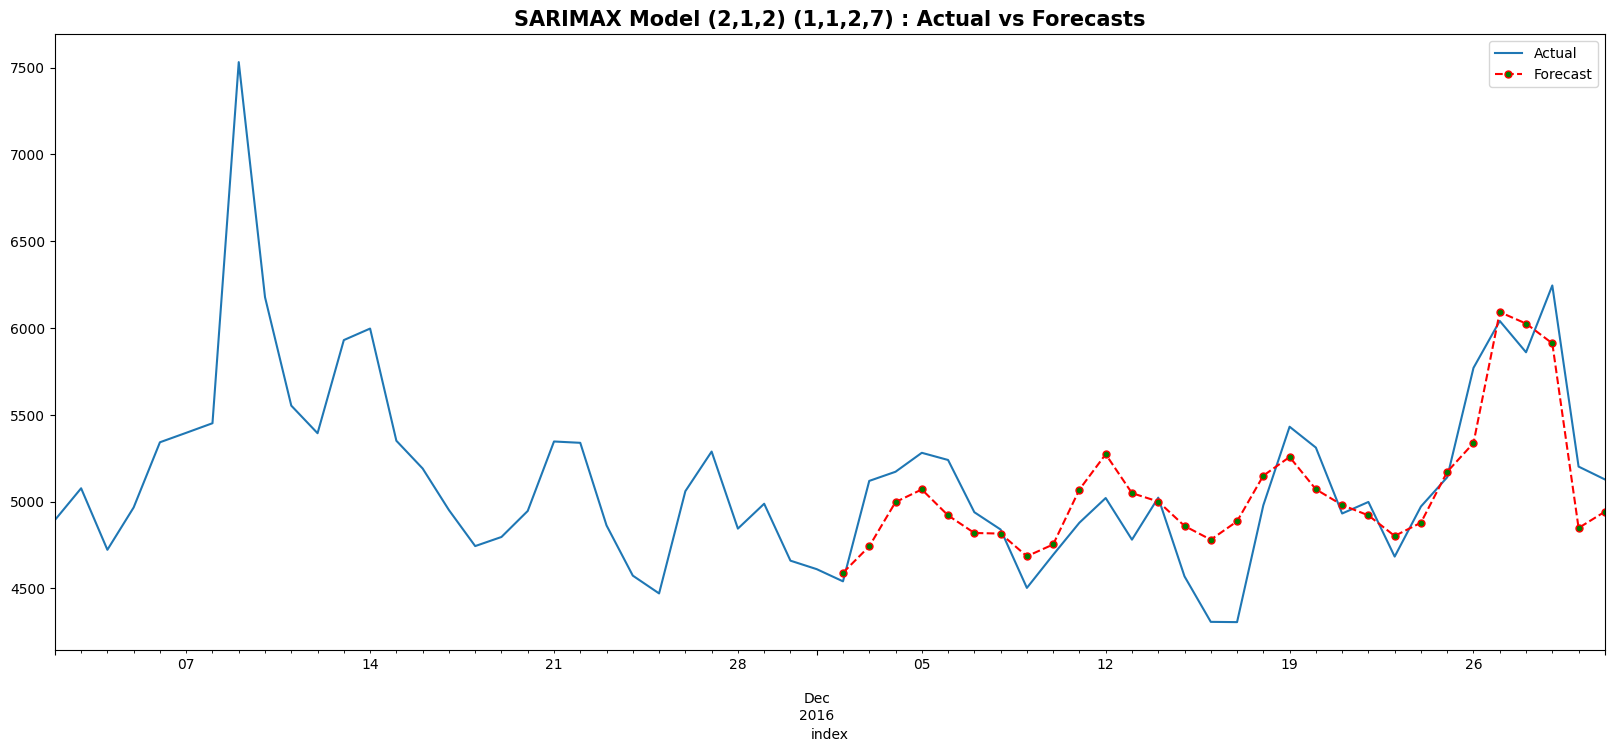


RMSE of Model : 246.918
MAPE of Model : 0.04054


In [104]:
exog = exog_var['Exog'].to_numpy()
time_series = aggregated_data.English
test_size= 0.1
p,d,q, P,D,Q,s = 2,1,2,1,1,2,7
n = 30
sarimax_model(time_series, n, p=p, d=d, q=q, P=P, D=D, Q=Q, s=s, exog = exog)

### **Hyperparameter Tuning For All Other Languages**

In [105]:
def pipeline_sarimax_grid_search_without_exog(languages, data, n, param, d_param, s_param):

    best_param_df  = pd.DataFrame(columns = ['language','p','d', 'q', 'P','D','Q','s','mape'])
    for lang in languages:
        print('')
        print('')
        print(f'--------------------------------------------------------------')
        print(f'          Finding best parameters for {lang}                  ')
        print(f'--------------------------------------------------------------')
        counter = 0
        time_series = data[lang]
        best_mape = 100

        #Creating loop for every paramater to fit SARIMAX model
        for p in param:
            for d in d_param:
                for q in param:
                    for P in param:
                        for D in d_param:
                            for Q in param:
                                for s in s_param:
                                    #Creating Model
                                    model = SARIMAX(time_series[:-n],
                                                    order=(p,d,q),
                                                    seasonal_order=(P, D, Q, s),
                                                    initialization='approximate_diffuse')
                                    model_fit = model.fit()

                                    #Creating forecast from Model
                                    model_forecast = model_fit.forecast(n, dynamic = True)

                                    #Calculating errors for results
                                    actuals = time_series.values[-n:]
                                    errors = time_series.values[-n:] - model_forecast.values

                                    #Calculating MAPE & RMSE
                                    mape = np.mean(np.abs(errors)/ np.abs(actuals))

                                    counter += 1

                                    if (mape < best_mape):
                                        best_mape = mape
                                        best_p = p
                                        best_d = d
                                        best_q = q
                                        best_P = P
                                        best_D = D
                                        best_Q = Q
                                        best_s = s
                                    else: pass

                    #print statement to check progress of Loop
                    print(f'Possible Combination: {counter} out of {(len(param)**4)*len(s_param)*(len(d_param)**2)} calculated')

        best_mape = np.round(best_mape, 5)
        print(f'--------------------------------------------------------------')
        print(f'Minimum MAPE for {lang} = {best_mape}')
        print(f'Corresponding Best Parameters are {best_p , best_d, best_q, best_P, best_D, best_Q, best_s}')
        print(f'--------------------------------------------------------------')

        best_param_row = [lang, best_p, best_d, best_q, best_P, best_D, best_Q, best_s, best_mape]
        best_param_df.loc[len(best_param_df)] = best_param_row

    return best_param_df


In [106]:
languages = aggregated_data.columns
n = 30
param = [0,1,2]
d_param = [0,1]
s_param = [7]


best_param_df = pipeline_sarimax_grid_search_without_exog(languages, aggregated_data, n, param, d_param, s_param)




--------------------------------------------------------------
          Finding best parameters for Chinese                  
--------------------------------------------------------------
Possible Combination: 18 out of 324 calculated
Possible Combination: 36 out of 324 calculated
Possible Combination: 54 out of 324 calculated
Possible Combination: 72 out of 324 calculated
Possible Combination: 90 out of 324 calculated
Possible Combination: 108 out of 324 calculated
Possible Combination: 126 out of 324 calculated
Possible Combination: 144 out of 324 calculated
Possible Combination: 162 out of 324 calculated
Possible Combination: 180 out of 324 calculated
Possible Combination: 198 out of 324 calculated
Possible Combination: 216 out of 324 calculated
Possible Combination: 234 out of 324 calculated
Possible Combination: 252 out of 324 calculated
Possible Combination: 270 out of 324 calculated
Possible Combination: 288 out of 324 calculated
Possible Combination: 306 out of 324 calculat

In [107]:
best_param_df.sort_values(['mape'], inplace = True)
best_param_df

,language,p,d,q,P,D,Q,s,mape
0,Chinese,0,1,0,1,0,2,7,0.03074
5,Russian,0,0,2,1,0,1,7,0.04166
1,English,2,0,1,0,1,2,7,0.05273
2,French,0,0,2,2,1,2,7,0.06359
3,German,0,1,1,1,0,1,7,0.06578
4,Japenese,0,1,2,2,1,0,7,0.07122
6,Spanish,0,1,0,2,1,0,7,0.08561


In [108]:
def plot_best_SARIMAX_model(languages, data, n, best_param_df):

    for lang in languages:
        #fetching respective best parameters for that language
        p = best_param_df.loc[best_param_df['language'] == lang, ['p']].values[0][0]
        d = best_param_df.loc[best_param_df['language'] == lang, ['d']].values[0][0]
        q = best_param_df.loc[best_param_df['language'] == lang, ['q']].values[0][0]
        P = best_param_df.loc[best_param_df['language'] == lang, ['P']].values[0][0]
        D = best_param_df.loc[best_param_df['language'] == lang, ['D']].values[0][0]
        Q = best_param_df.loc[best_param_df['language'] == lang, ['Q']].values[0][0]
        s = best_param_df.loc[best_param_df['language'] == lang, ['s']].values[0][0]

        #Creating language time-series
        time_series = data[lang]

        #Creating SARIMAX Model with order(p,d,q) & seasonal_order=(P, D, Q, s)
        model = SARIMAX(time_series[:-n],
                        order =(p,d,q),
                        seasonal_order=(P, D, Q, s),
                        initialization='approximate_diffuse')
        model_fit = model.fit()

        #Creating forecast for last n-values
        model_forecast = model_fit.forecast(n, dynamic = True)

        #Calculating MAPE & RMSE
        actuals = time_series.values[-n:]
        errors = time_series.values[-n:] - model_forecast.values

        mape = np.mean(np.abs(errors)/ np.abs(actuals))
        rmse = np.sqrt(np.mean(errors**2))

        print('')
        print('')
        print(f'-----------------------------------------------------------------------------------------')
        print(f'        SARIMAX model for {lang} Time Series                                             ')
        print(f'        Parameters of Model : ({p},{d},{q}) ({P},{D},{Q},{s})                            ')
        print(f'        MAPE of Model       : {np.round(mape,5)}                                         ')
        print(f'        RMSE of Model       : {np.round(rmse,3)}                                         ')
        print(f'-----------------------------------------------------------------------------------------')

        #plotting Actual & Forecasted values
        time_series.index = time_series.index.astype('datetime64[ns]')
        model_forecast.index = model_forecast.index.astype('datetime64[ns]')
        plt.figure(figsize = (20,8))
        time_series[-60:].plot(label = 'Actual')
        model_forecast[-60:].plot(label = 'Forecast', color = 'red',
                                  linestyle='dashed', marker='o',markerfacecolor='green', markersize=5)
        plt.legend(loc="upper right")
        plt.title(f'SARIMAX Model ({p},{d},{q}) ({P},{D},{Q},{s}) : Actual vs Forecasts', fontsize = 15, fontweight = 'bold')
        plt.show()

    return 0




-----------------------------------------------------------------------------------------
        SARIMAX model for Chinese Time Series                                             
        Parameters of Model : (0,1,0) (1,0,2,7)                            
        MAPE of Model       : 0.03074                                         
        RMSE of Model       : 14.486                                         
-----------------------------------------------------------------------------------------


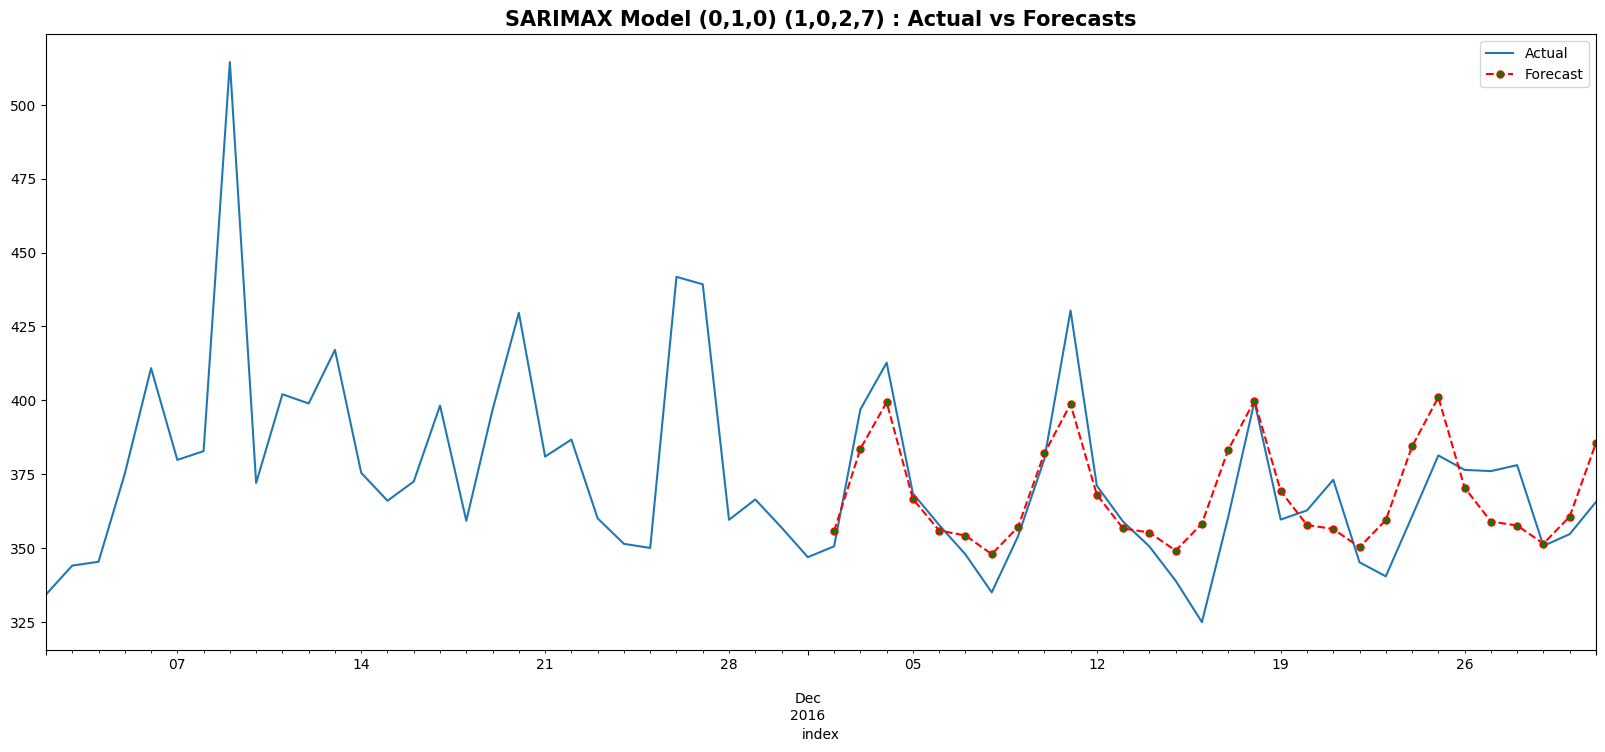



-----------------------------------------------------------------------------------------
        SARIMAX model for English Time Series                                             
        Parameters of Model : (2,0,1) (0,1,2,7)                            
        MAPE of Model       : 0.05273                                         
        RMSE of Model       : 390.195                                         
-----------------------------------------------------------------------------------------


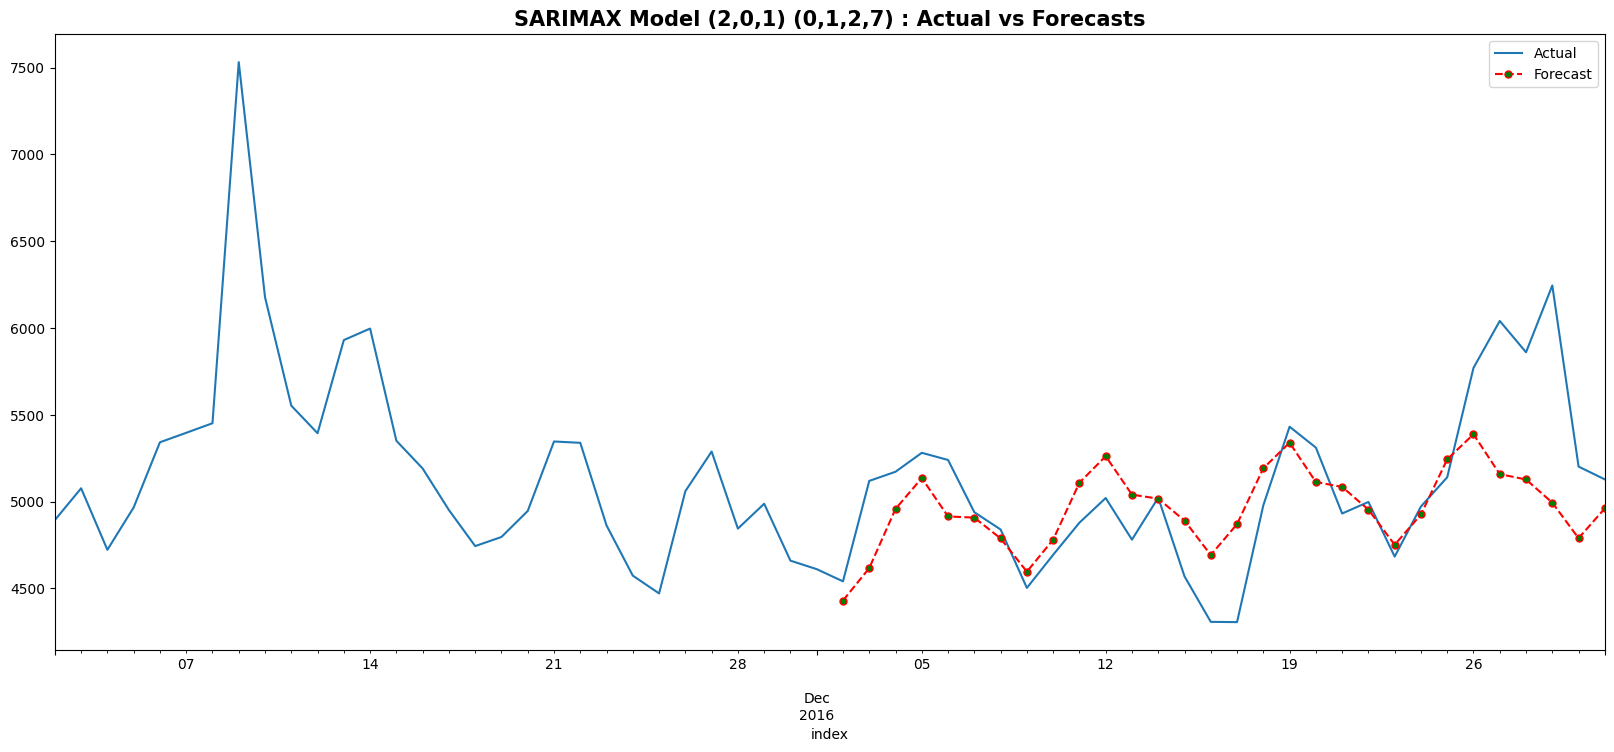



-----------------------------------------------------------------------------------------
        SARIMAX model for French Time Series                                             
        Parameters of Model : (0,0,2) (2,1,2,7)                            
        MAPE of Model       : 0.06359                                         
        RMSE of Model       : 72.572                                         
-----------------------------------------------------------------------------------------


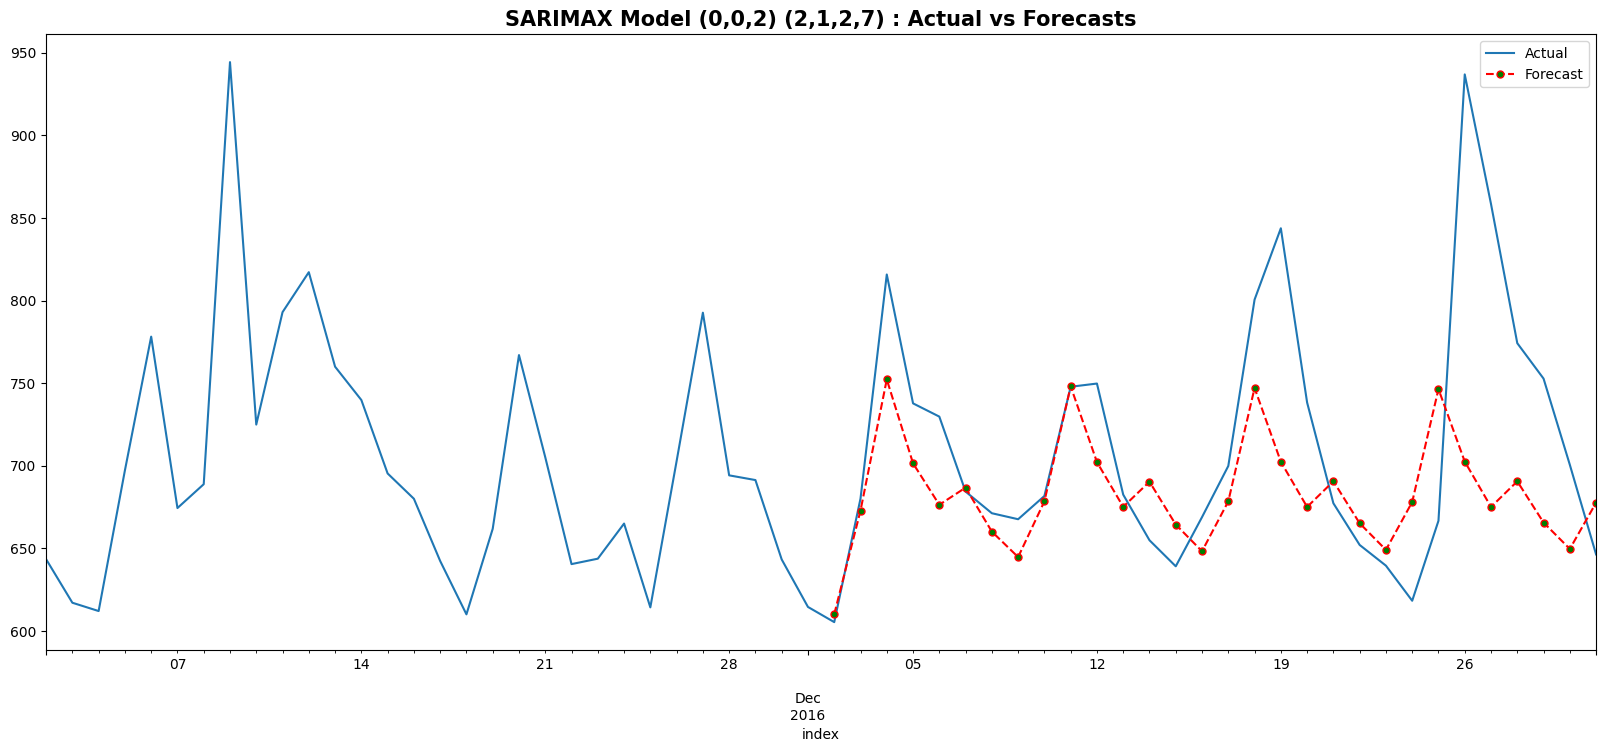



-----------------------------------------------------------------------------------------
        SARIMAX model for German Time Series                                             
        Parameters of Model : (0,1,1) (1,0,1,7)                            
        MAPE of Model       : 0.06578                                         
        RMSE of Model       : 110.62                                         
-----------------------------------------------------------------------------------------


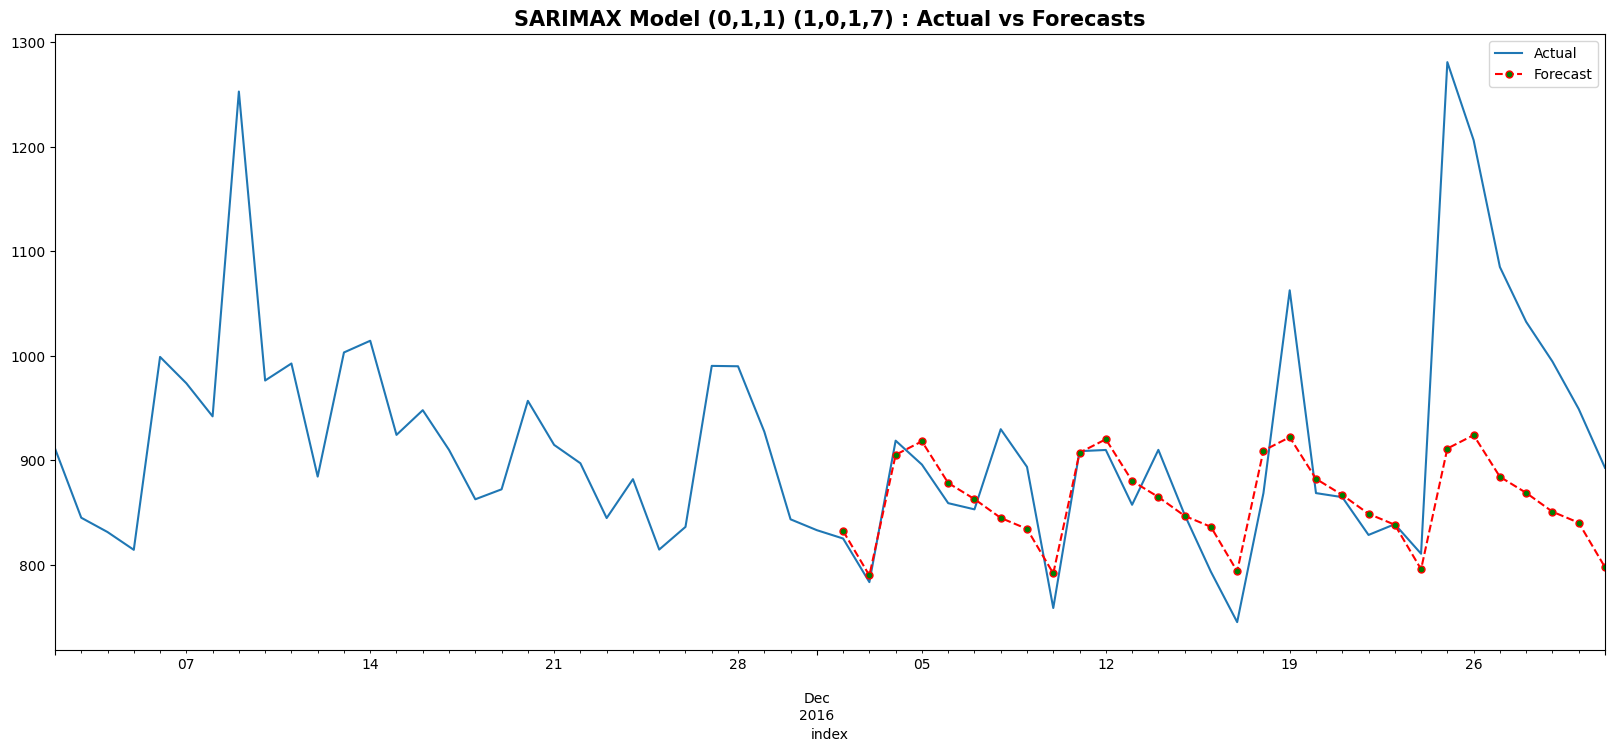



-----------------------------------------------------------------------------------------
        SARIMAX model for Japenese Time Series                                             
        Parameters of Model : (0,1,2) (2,1,0,7)                            
        MAPE of Model       : 0.07122                                         
        RMSE of Model       : 90.833                                         
-----------------------------------------------------------------------------------------


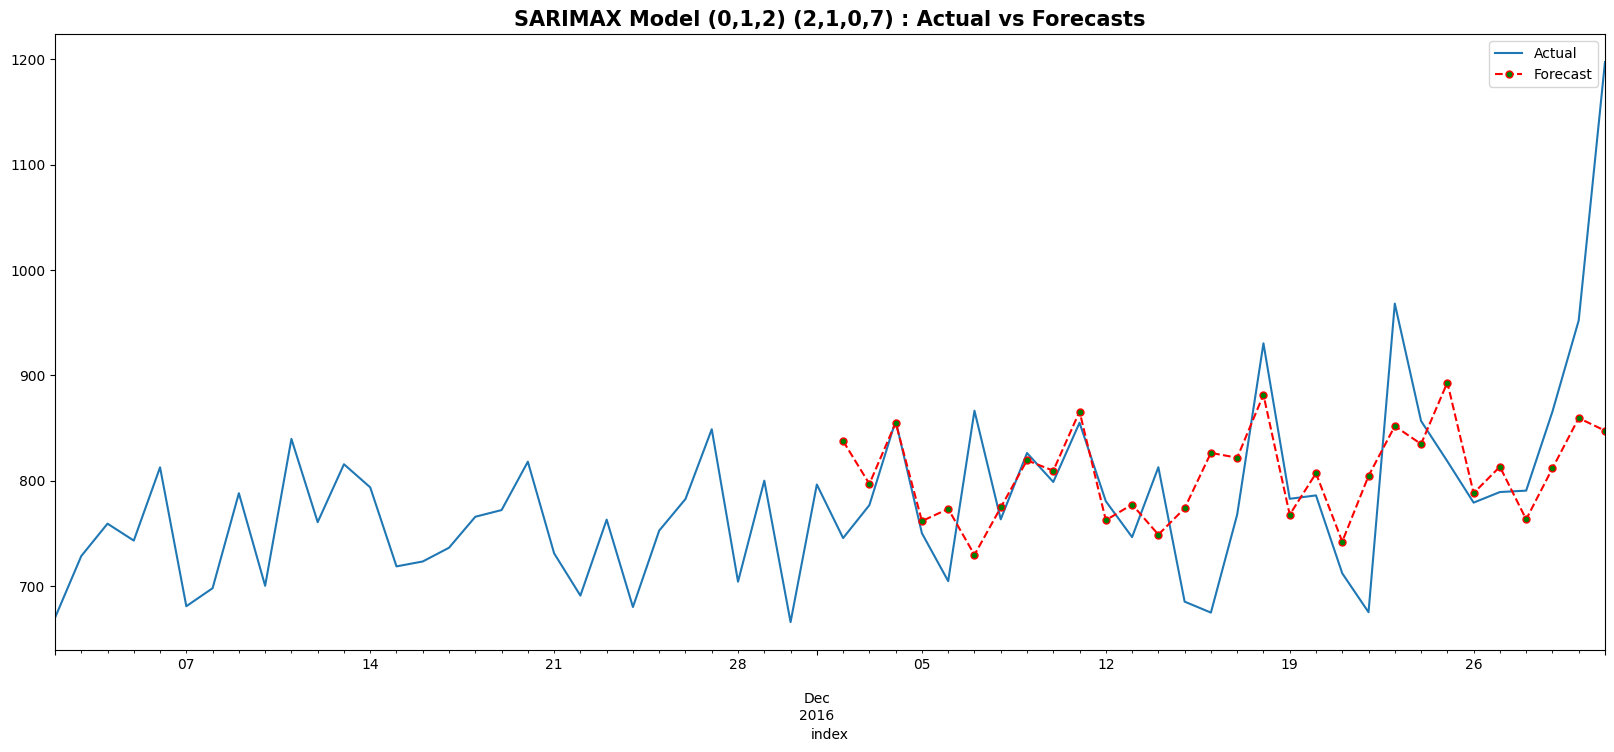



-----------------------------------------------------------------------------------------
        SARIMAX model for Russian Time Series                                             
        Parameters of Model : (0,0,2) (1,0,1,7)                            
        MAPE of Model       : 0.04166                                         
        RMSE of Model       : 52.025                                         
-----------------------------------------------------------------------------------------


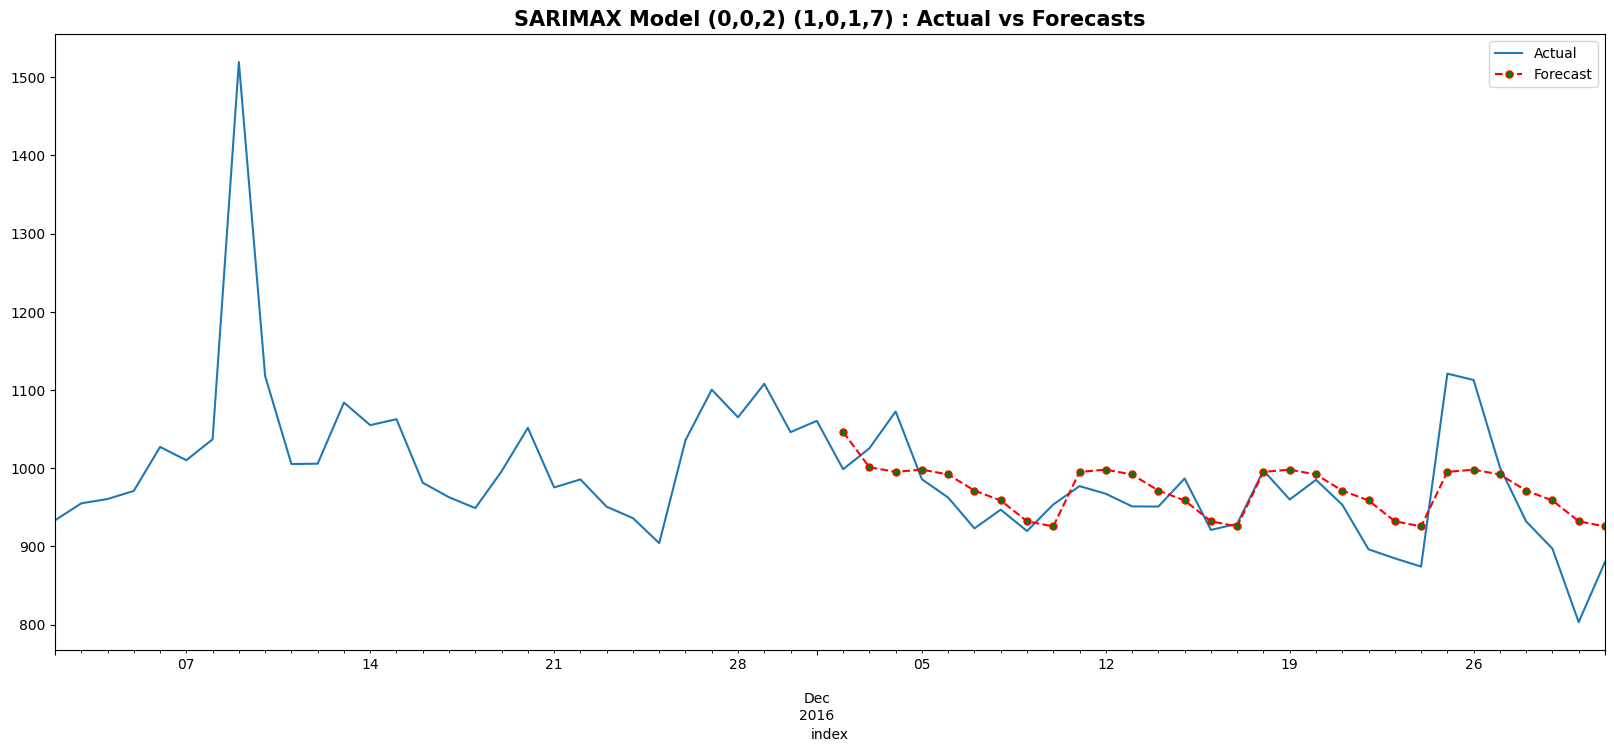



-----------------------------------------------------------------------------------------
        SARIMAX model for Spanish Time Series                                             
        Parameters of Model : (0,1,0) (2,1,0,7)                            
        MAPE of Model       : 0.08561                                         
        RMSE of Model       : 109.03                                         
-----------------------------------------------------------------------------------------


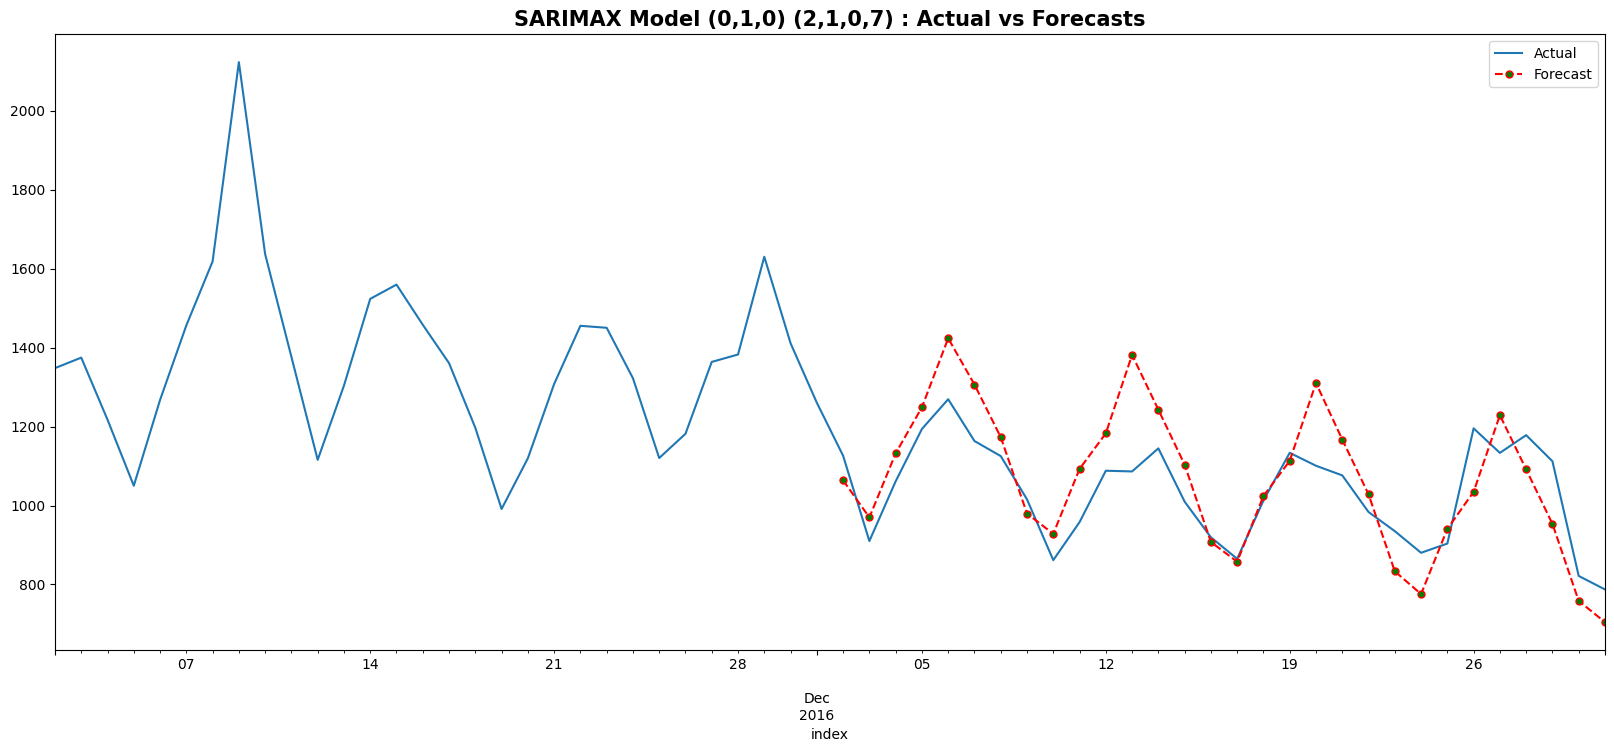

0

In [109]:
#Plotting SARIMAX model for each Language Time Series
languages = aggregated_data.columns
n = 30
plot_best_SARIMAX_model(languages, aggregated_data, n, best_param_df)


# **FORECASTING USING PROPHET**

In [110]:
import io, os, sys, setuptools, tokenize


In [111]:
!pip install prophet

import prophet

from prophet import Prophet

In [112]:
time_series = aggregated_data
time_series = time_series.reset_index()
time_series = time_series[['index', 'English']]
time_series.columns = ['ds', 'y']
exog = exog_var.copy(deep = True)
time_series['exog'] = exog.values

In [113]:
time_series

,ds,y,exog
0,2015-07-01,3513.862203,0
1,2015-07-02,3502.511407,0
2,2015-07-03,3325.357889,0
3,2015-07-04,3462.054256,0
4,2015-07-05,3575.520035,0
...,...,...,...
545,2016-12-27,6040.680728,1
546,2016-12-28,5860.227559,1
547,2016-12-29,6245.127510,1
548,2016-12-30,5201.783018,0


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsorlvglt/3jdpqrkx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsorlvglt/hbmmr8ed.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=97830', 'data', 'file=/tmp/tmpsorlvglt/3jdpqrkx.json', 'init=/tmp/tmpsorlvglt/hbmmr8ed.json', 'output', 'file=/tmp/tmpsorlvglt/prophet_modeliphhjsoh/prophet_model-20241030190349.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:03:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:03:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


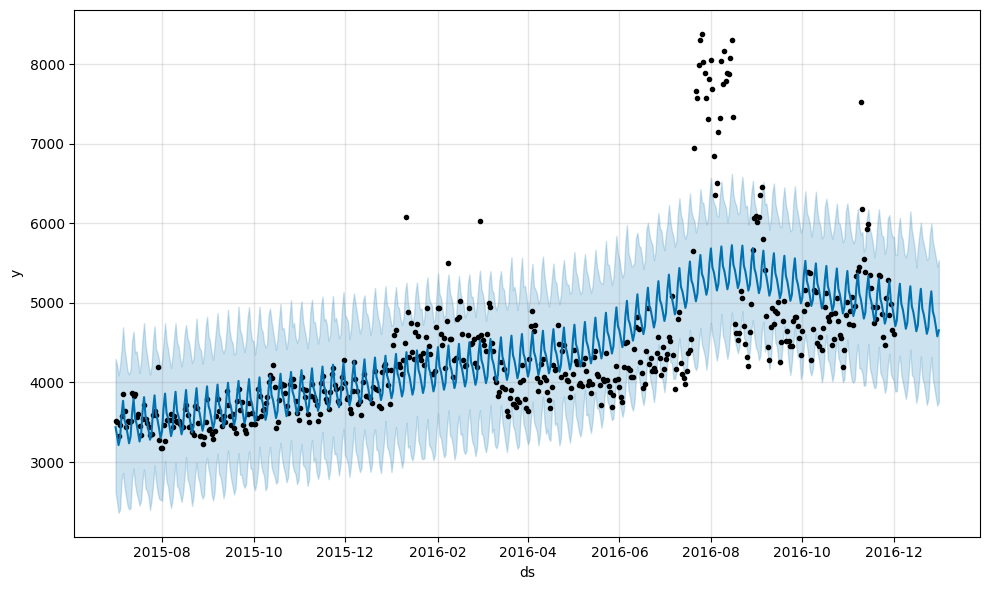

In [114]:
prophet1 = Prophet(weekly_seasonality=True)
prophet1.fit(time_series[['ds', 'y']][:-30])
future = prophet1.make_future_dataframe(periods=30, freq= 'D')
forecast = prophet1.predict(future)
fig1 = prophet1.plot(forecast)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsorlvglt/shapjtox.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsorlvglt/sh9yy5lh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=74183', 'data', 'file=/tmp/tmpsorlvglt/shapjtox.json', 'init=/tmp/tmpsorlvglt/sh9yy5lh.json', 'output', 'file=/tmp/tmpsorlvglt/prophet_model5wstwxte/prophet_model-20241030190400.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:04:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:04:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


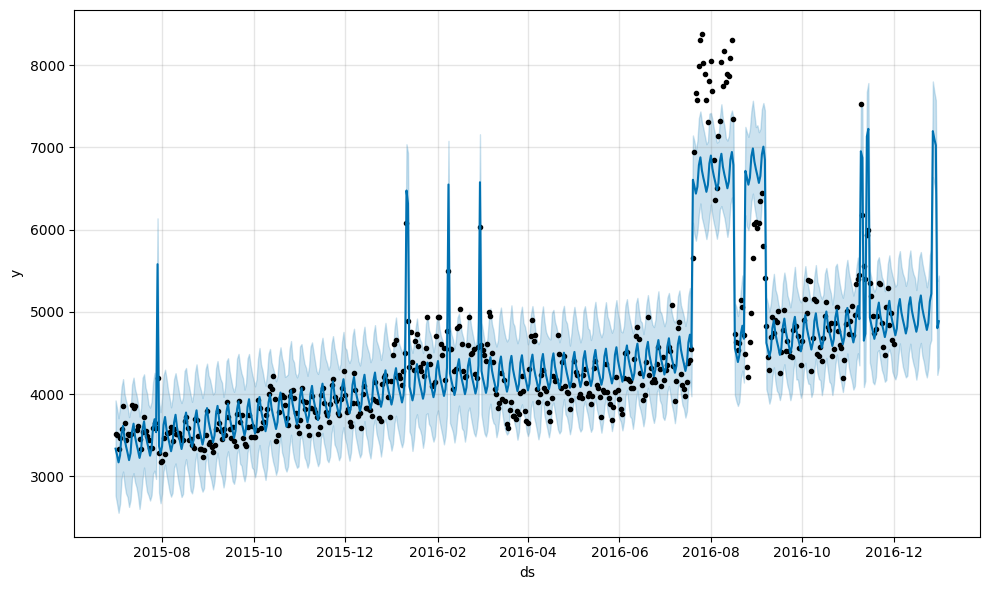

In [115]:
prophet2 = Prophet(weekly_seasonality=True)
prophet2.add_regressor('exog')
prophet2.fit(time_series[:-30])
#future2 = prophet2.make_future_dataframe(periods=30, freq= 'D')
forecast2 = prophet2.predict(time_series)
fig2 = prophet2.plot(forecast2)

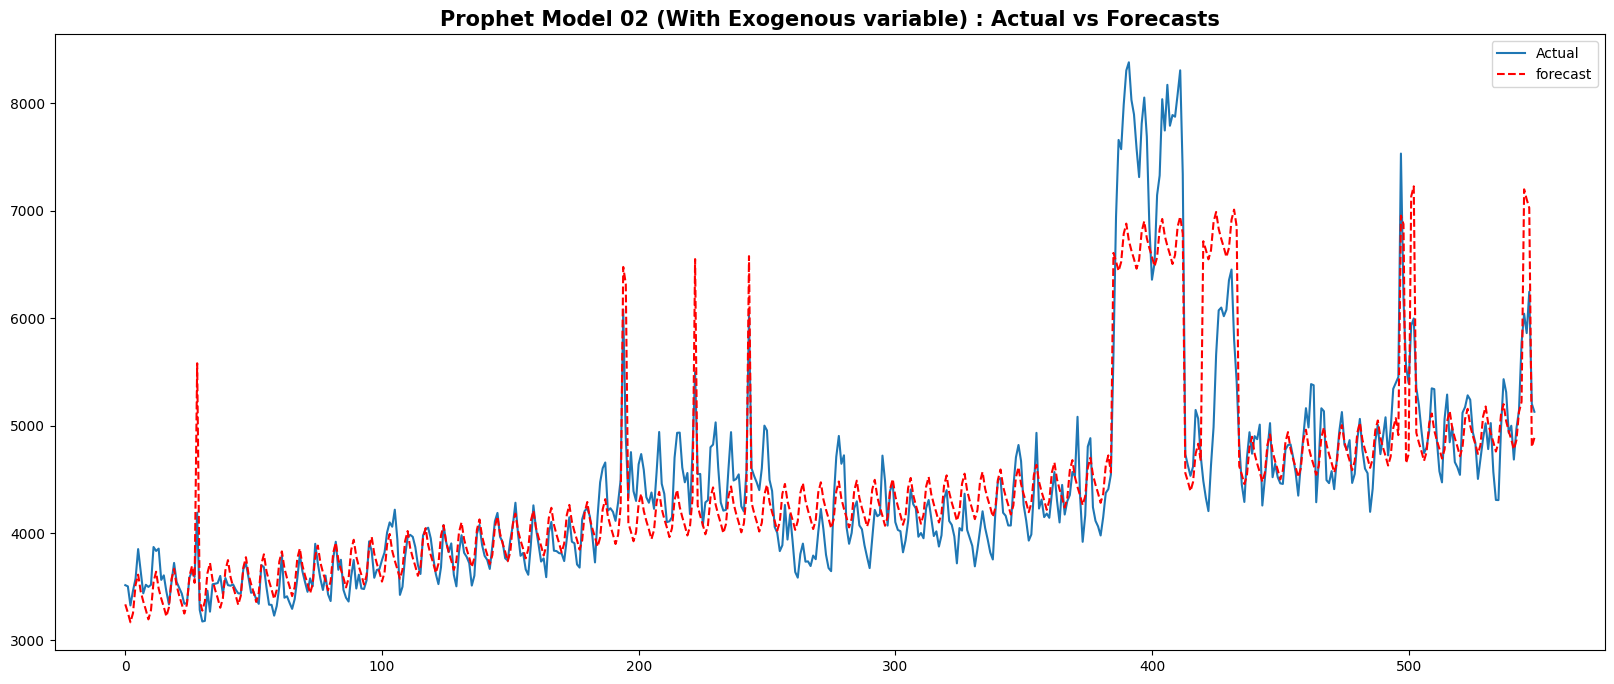

In [116]:
actual = time_series['y'].values
forecast = forecast2['yhat'].values

plt.figure(figsize = (20,8))
plt.plot(actual, label = 'Actual')
plt.plot(forecast, label = 'forecast', color = 'red', linestyle='dashed')
plt.legend(loc="upper right")
plt.title(f'Prophet Model 02 (With Exogenous variable) : Actual vs Forecasts', fontsize = 15, fontweight = 'bold')
plt.show()

In [117]:
errors = abs(actual - forecast)
mape = np.mean(errors/abs(actual))
mape

0.05945140053559279

# **BUSINESS INSIGHTS ✌**

**1. Language Distribution : ---> Diverse Language Usage :**

- There are seven languages represented in the data, with **English being the most prevalent (16.6%)**, followed by Japanese (14.1%) and German (12.8%).

- The presence of a significant percentage of **unknown language entries (12.3%)** indicates potential gaps in data collection or user engagement from non-English speaking users.

**2. Access Types : ---> User Access Trends :**

-  The **majority of access (51.23%)** is through **all-access** methods, indicating users prefer flexibility.

-  **Mobile web access (24.77%)** is also significant, suggesting a growing trend towards mobile users.

- **Desktop access is slightly lower (23.99%)**, indicating a shift in user behavior towards mobile and multi-platform access.

**3. Access Origins : ---> High Agent Access :**

-  With 75.93% of traffic coming from agents, there is a **strong reliance on automated systems or bots**, which could affect the accuracy of engagement metrics and may require strategies to distinguish between human and bot traffic.

**4. Stationarity of Time Series : ---> Non-Stationary Languages:**

-  The time series for page visits in languages like **English, German, Japanese, and Chinese are Non-Stationary**, suggesting trends or seasonal effects that need to be accounted for in forecasting models.

**5. Weekly Cycle : ---> Weekly Engagement Patterns:**

-  The presence of a **7-period cycle** indicates that user engagement fluctuates weekly, which can help in planning marketing and content strategies.

# **RECOMMENDATIONS 🤝**

**1. Targeted Advertising : ---> Maximize Ads on English Pages :**

-  Given that English has the highest number of pages and users, prioritize advertising efforts and promotions on English-language content to maximize ROI.

- Consider creating campaigns that appeal specifically to English-speaking audiences.

**2. Enhance Mobile Experience : ---> Optimize Mobile Platforms :**

-  Since a significant portion of access comes from mobile web (24.77%), ensure that the mobile experience is optimized.

- This includes faster load times, mobile-friendly design, and easier navigation.

**3. Data Collection Improvement : Address Unknown Language Entries :**

- Investigate the 12.3% of entries classified as unknown language.

- Improving data collection methods can enhance understanding of user demographics and improve overall user engagement strategies.

**4. Developing Insights from Stationarity Tests : ---> Modeling Non-Stationary Data :**

- For languages with non-stationary time series, apply appropriate differencing (d=1) in ARIMA models to accurately forecast page visits.

- This will help in understanding trends and making informed decisions on content strategy and marketing initiatives.

**5. Content Scheduling : ---> Leverage Weekly Patterns :**

- Utilize insights from the 7-period cycle in user engagement to schedule content releases and marketing campaigns.

- Align promotional activities with peak engagement periods to increase visibility and user interaction.

**6. Analyze Bot Traffic : ---> Filter Bot Traffic from Metrics :**

-  Given the high percentage of agent access (75.93%), develop a strategy to filter out bot traffic from engagement metrics to gain a clearer understanding of genuine user behavior.


By focusing on these insights and implementing the recommended actions, your organization can enhance user engagement, optimize content strategies, and drive performance across diverse languages and access types.

# **QUESTIONNAIRE ❓📝✔️**


**1. What does the decomposition of series do?**

- The decomposition of a time series refers to the process of separating a timeseries into its components, such as trend, seasonality, and residuals.

- These components are intended to represent different underlying patterns in the data. The idea behind decomposition is to break down a complex time series into simpler components that can be more easily understood and analyzed.

- Trend component represents the underlying pattern in the data over time, reflecting long-term changes.

- Seasonality component represents regular patterns that repeat over a fixed interval, such as daily, weekly, or yearly.

- Residual component represents the remaining random fluctuations in the data after removing the trend and seasonality components.

- Decomposition is often used in time series analysis to identify and isolate different patterns in the data and to forecast future values. It is also used to remove seasonality and trend components from the data before applying statistical or machine learning models to the residuals, as this can help to improve the performance of these models.



**2. What level of differencing gave you a stationary series?**

- Stationarity is an important property of a time series because many time series analysis techniques assume that the time series is stationary.

- A time series is stationary if its mean, variance, and autocorrelation structure are constant over time.

- Differencing is a common technique used to make a time series stationary.

- It involves subtracting the value of the time series at a previous time step from the current time step.

- This can help to remove trend and seasonality components from the data, making it more stationary.

- The order of differencing refers to the number of times the differencing operation is performed.

In this case study, differencing once yield a stationary time series.


**3. Difference Between ARIMA, SARIMA & SARIMAX.**


---

  **ARIMA** (AutoRegressive Integrated Moving Average): **bold text**
  
   - This is a statistical model for time series data that accounts for both autoregression (the use of past values to predict future values) and moving average (the use of the residuals of past predictions to predict future values).
   
   - It is a flexible method for modeling non-stationary time series data and can be used for both univariate and multivariate time series.
   
   - ARIMA models are denoted by the notations ARIMA(p, d, q), where p is the order of the autoregression component, d is the order of differencing used to make the time series stationary, and q is the order of the moving average component.



---


  **SARIMA** **(Seasonal AutoRegressive Integrated Moving Average):**

  - This is a variation of ARIMA that accounts for both seasonality and non-stationarity in time series data.
  
  - Seasonality refers to repeating patterns in the data over fixed time intervals, such as daily, weekly, or yearly. SARIMA models are denoted by the notations SARIMA(p, d, q)(P, D, Q, S), where p, d, and q are the same as in ARIMA models, P is the order of the seasonal autoregression component, D is the order of seasonal differencing, Q is the order of the seasonal moving average component, and S is the number of seasons in the data.



---


  **SARIMAX** **(Seasonal AutoRegressive Integrated Moving Average with exogenous regressors):**
  
  - This is an extension of SARIMA that allows for the inclusion of exogenous variables, or variables that are not part of the time series data, in the modeling process.

  - SARIMAX models are useful when the time series data is influenced by other variables that are not part of the time series data, and can provide more accurate forecasts.

  - SARIMAX models are denoted by the notations SARIMAX(p, d, q)(P, D, Q, S)x, where p, d, q, P, D, Q, and S are the same as in SARIMA models and x represents the number of exogenous variables included in the model.

  - The equation for a SARIMA (Seasonal AutoRegressive Integrated Moving Average) model can be expressed as follows:

  **ARIMA(p, d, q)(P, D, Q, S):**

   y(t) = c + φ1 * y(t-1) + φ2 * y(t-2) + ... + φp * y(t-p)
            + Θ1 * e(t-1) + Θ2 * e(t-2) + ... + Θq * e(t-q)
            + δ * y(t-S) + Φ1 * y(t-S-1) + Φ2 * y(t-S-2) + ... + ΦP * y(t-S-P)
            + Θ1 * e(t-S-1) + Θ2 * e(t-S-2) + ... + ΘQ * e(t-S-Q) + e(t)

          where:

          y(t) is the value of the time series at time step t.
          c is a constant.
          φ1, φ2, ..., φp are the autoregression coefficients.
          Θ1, Θ2, ..., Θq are the moving average coefficients.
          δ is a coefficient for the seasonal autoregression term.
          Φ1, Φ2, ..., ΦP are the seasonal autoregression coefficients.
          Θ1, Θ2, ..., ΘQ are the seasonal moving average coefficients.
          e(t), e(t-1), ..., e(t-q), e(t-S), e(t-S-1), ..., e(t-S-Q) are the residuals.

 - In a SARIMA model, the order of differencing (d) is used to make the time series stationary, the autoregression and moving average components (p and q) are used to model the autocorrelation structure of the residuals, and the seasonal components (P, D, Q, and S) are used to model the seasonal patterns in the data.

  - The coefficients in the model are estimated using maximum likelihood estimation or other optimization techniques, and the residuals are used to assess the goodness-of-fit of the model.


**4. Compare the number of views in different languages**

<Axes: xlabel='Language'>

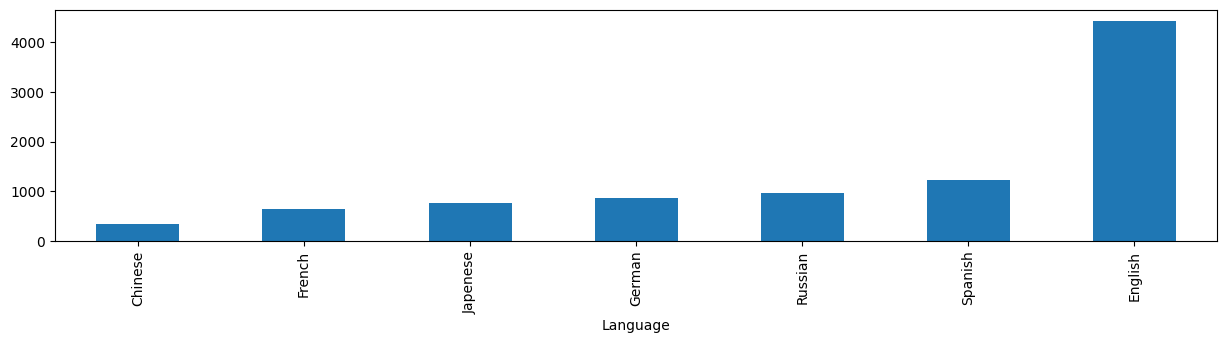

In [118]:
aggregated_data.mean().sort_values().plot(kind = 'bar')


**INFERENCE:**

- It is evident that **ENGLISH** is the **most viewed language**, while **CHINESE** **ranks** as the **least viewed** language.

**5. What other methods other than grid search would be suitable to get the model for all languages?**

  When estimating the values of p, q, and d from the ACF and PACF plots of a time series, the following steps can be taken:
  - Determine if the time series is stationary by conducting an augmented Dickey-Fuller test.

  - If the time series is stationary, attempt to fit an ARMA model. If it is non-stationary, determine the value of d.
  - If stationarity is achieved, plot the autocorrelation and partial autocorrelation graphs of the data.
  - Plot the partial autocorrelation graph (PACF) to determine the value of p, as the cut-off point in the PACF is equal to p.
  - Plot the autocorrelation graph (ACF) to determine the value of q, as the cut-off point in the ACF is equal to q.



---



---




**BY**

**DEEPAK RAJ M**

**DSML JULY 2023**